# Viral Roulette
## Algorithm or Skill? A Monte Carlo Simulation of Creator Strategy and Emergent Inequality on TikTok

**Author:** Rayyan Maan &nbsp;·&nbsp; **Version:** 1.0 &nbsp;·&nbsp; [Repository](https://github.com/rayyanmaan/viral-roulette)

This notebook is the complete, executable record of the project: it calibrates the model
from four real datasets, implements it, tests it, derives the theory, and runs all five
experiments end to end. Every figure and every number in the written report is produced here.

---

### Notebook index

| Appendix | Section | What it does |
|----------|---------|--------------|
| A0 | Setup | Imports, data paths, global configuration |
| A1 | Data calibration | Loading four real datasets and extracting model parameters |
| A1a | — | Creator profiles: follower Gini, engagement rate by tier |
| A1b | — | Hashtag dataset: per-topic like/share multipliers |
| A1c | — | Google Trends: log-normal lifecycle fitting |
| A1d | — | Published industry benchmarks (tier distribution, ER by tier) |
| A1e | — | Calibration summary table |
| A2 | Model implementation | `Creator`, `Algorithm`, `TrendEngine`, `Simulation` |
| A2a | — | `Creator` class |
| A2b | — | `Algorithm` class: the two-stage recommendation funnel |
| A2c | — | `TrendEngine` class |
| A2d | — | `Simulation` class |
| A2e | — | Monte Carlo runner |
| A3 | Correctness tests | Five unit tests that must pass before any experiment runs |
| A4 | Animation | Single-run animated follower trajectory |
| A5 | Theoretical analysis | Analytical derivations implemented as functions |
| A6 | Experiment 1 | Follower growth distribution by strategy |
| A7 | Experiment 2 | Survival rate and downside risk |
| A8 | Experiment 3 | Virality probability: simulation vs theory |
| A8b | Follow-up | Viral rate stratified by growth quartile |
| A9 | Experiment 4 | Lorenz curves and Gini coefficient |
| A10 | Experiment 5 | Sensitivity analysis heatmaps |
| A11 | CI summary | Confidence intervals for every key metric |

---
**Cross-reference:** the written report cites this notebook by appendix label (e.g. "see Appendix A2a").
Appendices are self-contained and run top to bottom.

> **Runtime:** Appendix A6 runs 4,000 full simulations and takes roughly 15–25 minutes.
> Everything before it runs in under a minute.


## Appendix A0 — Environment Setup and Global Configuration

In [1]:
# ============================================================
# APPENDIX A0: Environment Setup
#
# Imports, data paths, and every global constant used below.
# Run this cell first.
#
# Paths resolve automatically whether this notebook is run from a
# local clone of the repository or from Google Colab.
# ============================================================

import os
import sys
import subprocess
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    # Pull the repository (data included) so the notebook is self-contained.
    REPO = Path("/content/viral-roulette")
    if not REPO.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1",
             "https://github.com/rayyanmaan/viral-roulette.git", str(REPO)],
            check=True,
        )
else:
    # Local clone: this notebook lives in <repo>/notebooks/
    REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_DIR = REPO / "data"
FIG_DIR  = REPO / "assets" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Standard scientific stack
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation, PillowWriter
from matplotlib.colors import ListedColormap
from IPython.display import Image, display

# Scientific computing
from scipy import stats
from scipy.optimize import curve_fit
from scipy.special import erfc

# Utilities
from tqdm.auto import tqdm
import warnings
import time
from collections import namedtuple, defaultdict
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional

warnings.filterwarnings("ignore")

# -- Global random seed for reproducibility -------------------
GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)

# -- Data file paths ------------------------------------------
PATHS = {
    "profiles"  : DATA_DIR / "tiktok_profiles_dataset.csv",
    "hashtags"  : DATA_DIR / "tiktok_popular_hashtags_dataset.xlsx",
    "brat"      : DATA_DIR / "trends" / "brat_summer.csv",
    "corn"      : DATA_DIR / "trends" / "corn_kid.csv",
    "demure"    : DATA_DIR / "trends" / "demure.csv",
    "sea_shanty": DATA_DIR / "trends" / "sea_shanty.csv",
}

# -- Global visual style --------------------------------------
# Colour-blind-friendly palette; each strategy keeps one fixed
# colour in every figure in the notebook and the report.
STRATEGY_COLORS = {
    "niche"          : "#2E86AB",   # blue
    "trend_chaser"   : "#E84855",   # red
    "quality_focused": "#3BB273",   # green
    "random_baseline": "#F4A261",   # orange
}
STRATEGY_LABELS = {
    "niche"          : "Niche Specialist",
    "trend_chaser"   : "Trend Chaser",
    "quality_focused": "Quality-Focused",
    "random_baseline": "Random Baseline",
}
STRATEGIES = list(STRATEGY_COLORS.keys())

mpl.rcParams.update({
    "figure.dpi"       : 120,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "grid.linestyle"   : "--",
    "font.size"        : 11,
    "axes.titlesize"   : 13,
    "axes.labelsize"   : 11,
    "legend.fontsize"  : 10,
    "figure.facecolor" : "white",
})

# -- Simulation hyperparameters -------------------------------
N_CREATORS   = 30    # creators per simulation run
N_STEPS      = 60    # time steps per run (each step = 1 week)
N_MC_RUNS    = 1000  # Monte Carlo iterations per strategy
N_SENS_RUNS  = 30    # runs per grid cell in the sensitivity analysis
N_TEST_USERS = 100   # initial cohort size (Stage 1 exposure)

print(f"Repository root: {REPO}")
print("Verifying data files...")
for name, path in PATHS.items():
    status = "OK     " if Path(path).exists() else "MISSING"
    print(f"  [{status}] {name}: {Path(path).relative_to(REPO)}")
print("\nSetup complete. Proceed to Appendix A1.")


Repository root: /Users/rayyanafzal/viral-roulette
Verifying data files...
  [OK     ] profiles: data/tiktok_profiles_dataset.csv
  [OK     ] hashtags: data/tiktok_popular_hashtags_dataset.xlsx
  [OK     ] brat: data/trends/brat_summer.csv
  [OK     ] corn: data/trends/corn_kid.csv
  [OK     ] demure: data/trends/demure.csv
  [OK     ] sea_shanty: data/trends/sea_shanty.csv

Setup complete. Proceed to Appendix A1.


## Appendix A1 — Data Loading and Calibration

Before the simulation is built, we extract empirical parameters from three real data sources.
This calibration is what separates a grounded model from an arbitrary one.
Results from this section feed directly into the strategy parameter table (see report section 1.6).

### Appendix A1a — BrightData TikTok User Profiles

Loaded 1000 rows; 1000 after cleaning.
Follower range: 1 to 14,500,000
Engagement rate range: 0.00% to 63.38%

Real-world Gini coefficient (follower distribution): 0.9086

Engagement rate by tier (BrightData):
          ER_mean  ER_std    n
tier                          
Nano        0.853   4.136  595
Micro       0.232   0.649  193
Mid-tier    0.050   0.074  172
Macro       0.032   0.043   19
Mega        0.063   0.113   21


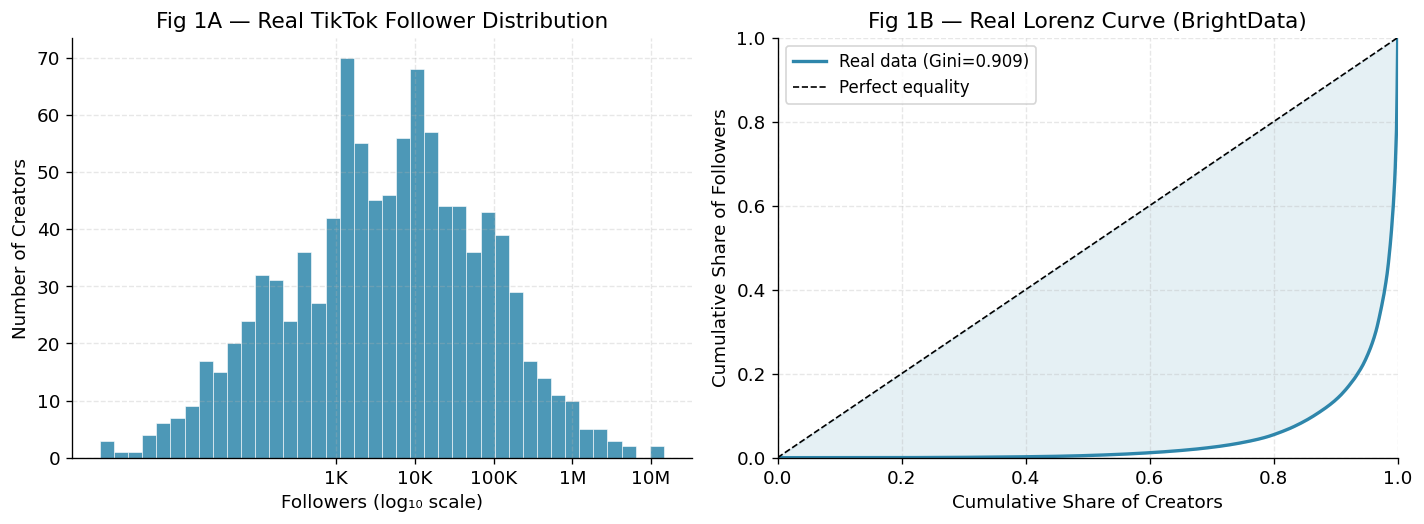


A1a complete. calibration_profiles stored.


In [2]:
# ============================================================
# APPENDIX A1a: BrightData TikTok User Profiles
#
# Purpose: extract two calibration targets from real creator data
#   (1) Gini coefficient of follower distribution → validation target
#   (2) Mean engagement rate by follower tier → parameter calibration
#
# Source: BrightData TikTok User Profiles Dataset (CSV, ~1000 rows)
# Columns used: followers, awg_engagement_rate, likes
# ============================================================

# ── Load and clean ───────────────────────────────────────────
profiles_raw = pd.read_csv(PATHS['profiles'])

# Keep only rows with valid follower counts and engagement rates
profiles = profiles_raw.dropna(subset=['followers', 'awg_engagement_rate']).copy()
profiles = profiles[profiles['followers'] > 0]
profiles = profiles[profiles['awg_engagement_rate'] >= 0]

print(f'Loaded {len(profiles_raw)} rows; {len(profiles)} after cleaning.')
print(f'Follower range: {profiles["followers"].min():,.0f} to {profiles["followers"].max():,.0f}')
print(f'Engagement rate range: {profiles["awg_engagement_rate"].min():.2f}% to {profiles["awg_engagement_rate"].max():.2f}%')

# ── Gini coefficient ─────────────────────────────────────────
def compute_gini(values: np.ndarray) -> float:
    """
    Compute the Gini coefficient of a 1-D array of non-negative values.

    Uses the standard sorted-array formula:
        G = (2 * sum(i * x_i)) / (n * sum(x_i)) - (n+1)/n
    where x_i are the values sorted in ascending order.

    Returns a float in [0, 1]: 0 = perfect equality, 1 = maximum inequality.
    """
    arr = np.sort(np.asarray(values, dtype=float))
    n = len(arr)
    if n == 0 or arr.sum() == 0:
        return 0.0
    index = np.arange(1, n + 1)
    return (2 * np.dot(index, arr)) / (n * arr.sum()) - (n + 1) / n


def compute_lorenz(values: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute the Lorenz curve for a 1-D array of non-negative values.

    Returns (cumulative_population_share, cumulative_value_share),
    both arrays of length len(values)+1, starting at (0, 0).
    """
    arr = np.sort(np.asarray(values, dtype=float))
    cum_share = np.concatenate([[0], np.arange(1, len(arr) + 1) / len(arr)])
    cum_val   = np.concatenate([[0], np.cumsum(arr) / arr.sum()])
    return cum_share, cum_val


real_gini = compute_gini(profiles['followers'].values)
lorenz_x_real, lorenz_y_real = compute_lorenz(profiles['followers'].values)
print(f'\nReal-world Gini coefficient (follower distribution): {real_gini:.4f}')

# ── Engagement rate by follower tier ─────────────────────────
# Tier boundaries match HypeAuditor definitions (benchmark report, p.24)
tier_bins   = [0, 10_000, 50_000, 500_000, 1_000_000, np.inf]
tier_labels = ['Nano', 'Micro', 'Mid-tier', 'Macro', 'Mega']

profiles['tier'] = pd.cut(
    profiles['followers'],
    bins=tier_bins,
    labels=tier_labels,
    right=False
)

er_by_tier_real = (
    profiles.groupby('tier', observed=True)['awg_engagement_rate']
    .agg(['mean', 'std', 'count'])
    .rename(columns={'mean': 'ER_mean', 'std': 'ER_std', 'count': 'n'})
)
print('\nEngagement rate by tier (BrightData):')
print(er_by_tier_real.round(3))

# ── Figure 1: Follower distribution and Lorenz curve ────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Panel A: Follower distribution (log scale)
ax = axes[0]
follower_vals = profiles['followers'].values
ax.hist(np.log10(follower_vals[follower_vals > 0]),
        bins=40, color='#2E86AB', edgecolor='white', linewidth=0.4, alpha=0.85)
ax.set_xlabel('Followers (log₁₀ scale)')
ax.set_ylabel('Number of Creators')
ax.set_title('Fig 1A — Real TikTok Follower Distribution')
tick_vals = [1e3, 1e4, 1e5, 1e6, 1e7]
ax.set_xticks(np.log10(tick_vals))
ax.set_xticklabels(['1K', '10K', '100K', '1M', '10M'])

# Panel B: Real Lorenz curve
ax = axes[1]
ax.plot(lorenz_x_real, lorenz_y_real, color='#2E86AB', lw=2, label=f'Real data (Gini={real_gini:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Perfect equality')
ax.fill_between(lorenz_x_real, lorenz_y_real, lorenz_x_real, alpha=0.12, color='#2E86AB')
ax.set_xlabel('Cumulative Share of Creators')
ax.set_ylabel('Cumulative Share of Followers')
ax.set_title('Fig 1B — Real Lorenz Curve (BrightData)')
ax.legend()
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_follower_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Store calibration output ─────────────────────────────────
# This dictionary is referenced by later cells.
calibration_profiles = {
    'real_gini'          : real_gini,
    'lorenz_x'           : lorenz_x_real,
    'lorenz_y'           : lorenz_y_real,
    'er_by_tier'         : er_by_tier_real,
    'follower_values'    : follower_vals,
    'tier_distribution'  : profiles['tier'].value_counts(normalize=True).to_dict(),
}
print('\nA1a complete. calibration_profiles stored.')

### Appendix A1b — TikTok Hashtag Dataset: Topic Engagement Multipliers

All columns: ['authorMeta/avatar', 'authorMeta/digg', 'authorMeta/fans', 'authorMeta/following', 'authorMeta/heart', 'authorMeta/id', 'authorMeta/name', 'authorMeta/nickName', 'authorMeta/signature', 'authorMeta/verified', 'authorMeta/video', 'commentCount', 'createTime', 'createTimeISO', 'diggCount', 'downloaded', 'effectStickers/0/ID', 'effectStickers/0/name', 'effectStickers/0/stickerStats/useCount', 'effectStickers/1/ID', 'effectStickers/1/name', 'effectStickers/1/stickerStats/useCount', 'hashtags/0/cover', 'hashtags/0/id', 'hashtags/0/name', 'hashtags/0/title', 'hashtags/1/cover', 'hashtags/1/id', 'hashtags/1/name', 'hashtags/1/title', 'id', 'mediaUrls/0', 'mentions/0', 'mentions/1', 'mentions/2', 'mentions/3', 'mentions/4', 'mentions/5', 'musicMeta/musicAlbum', 'musicMeta/musicAuthor', 'musicMeta/musicName', 'musicMeta/musicOriginal', 'musicMeta/playUrl', 'playCount', 'searchHashtag/name', 'searchHashtag/views', 'shareCount', 'text', 'videoMeta/duration', 'videoMeta/height', 'vid

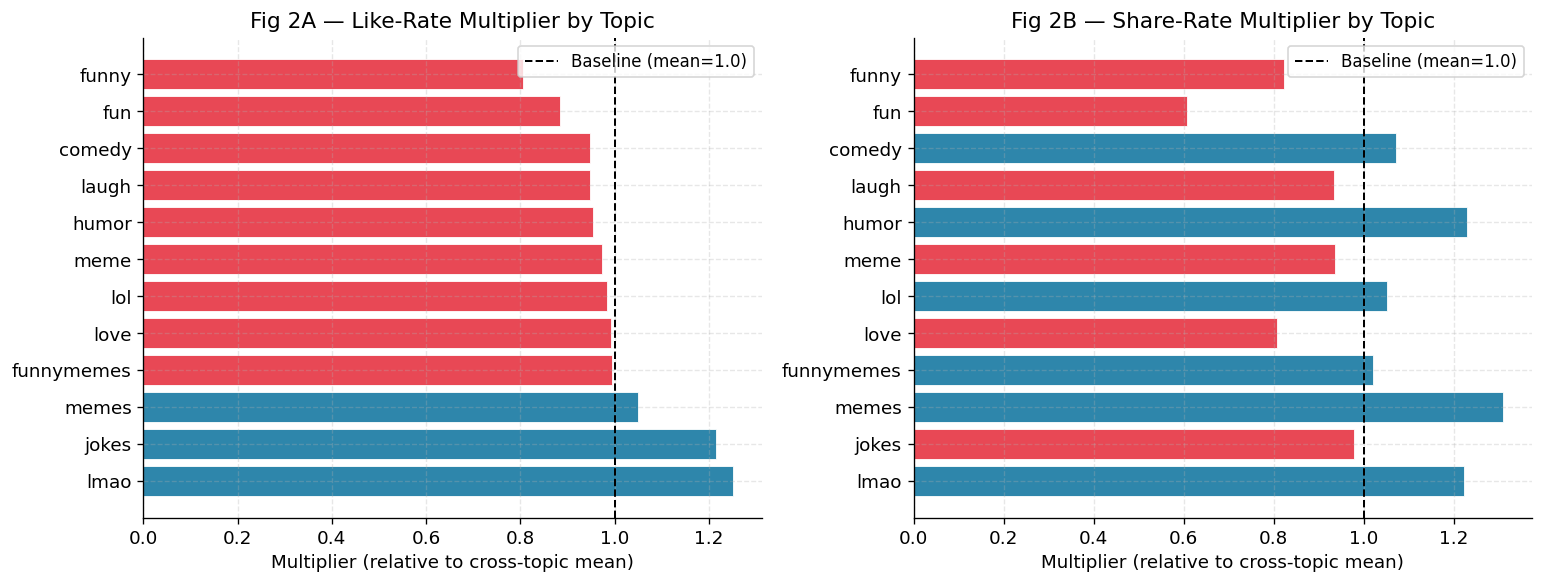


Topics available for content vectors: ['lmao', 'jokes', 'memes', 'funnymemes', 'love', 'lol', 'meme', 'humor', 'laugh', 'comedy', 'fun', 'funny']

A1b complete. calibration_hashtags stored.


In [23]:
# ============================================================
# APPENDIX A1b: TikTok Popular Hashtag Dataset
#
# Purpose: compute real like-rate and share-rate per CONTENT
# CATEGORY (hashtag), not per author. Topics are the actual
# hashtag categories scraped (meme, dance, fyp, etc.).
# These become the topic_engagement_multipliers in the simulation.
#
# Source: Kaggle TikTok Hashtag Dataset (XLSX), CC0 license
# Columns used: playCount, diggCount, shareCount, searchHashtag/name
# ============================================================

hashtags_raw = pd.read_excel(PATHS['hashtags'])

print("All columns:", hashtags_raw.columns.tolist())

# ── Targeted column selection ────────────────────────────────
# Use searchHashtag/name for topic extraction to avoid author metadata fields.
# Prioritise explicit hashtag columns before generic fallback keywords
# to avoid selecting unrelated metadata fields.

def find_col_priority(cols, priority_keywords, fallback_keywords):
    """
    Search columns by priority keywords first, then fallback.
    Returns the first matching column name, or None.
    """
    for kw in priority_keywords:
        for c in cols:
            if kw in c.lower():
                return c
    for kw in fallback_keywords:
        for c in cols:
            if kw in c.lower():
                return c
    return None

play_col  = find_col_priority(hashtags_raw.columns,
                               ['playcount', 'play_count'],
                               ['views', 'view'])
like_col  = find_col_priority(hashtags_raw.columns,
                               ['diggcount', 'digg'],
                               ['like'])
share_col = find_col_priority(hashtags_raw.columns,
                               ['sharecount', 'share'],
                               [])
# Prioritise searchHashtag columns before generic hashtag fields.
topic_col = find_col_priority(hashtags_raw.columns,
                               ['searchhashtag/name', 'searchhashtag'],
                               ['hashtag'])

assert play_col  is not None, f"No play column found in: {hashtags_raw.columns.tolist()}"
assert like_col  is not None, f"No like column found in: {hashtags_raw.columns.tolist()}"
assert share_col is not None, f"No share column found in: {hashtags_raw.columns.tolist()}"
assert topic_col is not None, f"No topic column found in: {hashtags_raw.columns.tolist()}"

print(f'\nUsing columns:')
print(f'  play  = {play_col}')
print(f'  like  = {like_col}')
print(f'  share = {share_col}')
print(f'  topic = {topic_col}')

# ── Clean ────────────────────────────────────────────────────
ht = hashtags_raw[[play_col, like_col, share_col, topic_col]].copy()
ht.columns = ['play_count', 'like_count', 'share_count', 'topic']

for col in ['play_count', 'like_count', 'share_count']:
    ht[col] = pd.to_numeric(ht[col], errors='coerce')

ht = ht.dropna()
ht = ht[ht['play_count'] > 0]
ht['topic'] = ht['topic'].astype(str).str.lower().str.strip()

# Remove generic/uninformative hashtags that don't represent content categories
# fyp and foryou are distribution tags, not content topics — keep them but
# they will get their own multiplier which is fine
EXCLUDE_TOPICS = {'nan', '', 'null', 'none'}
ht = ht[~ht['topic'].isin(EXCLUDE_TOPICS)]

print(f'\nRetained {len(ht)} rows after cleaning.')
print(f'Unique topics found: {ht["topic"].nunique()}')
print(f'Top 15 topics by row count:\n{ht["topic"].value_counts().head(15)}')

# ── Engagement rates ─────────────────────────────────────────
ht['like_rate']  = ht['like_count']  / ht['play_count']
ht['share_rate'] = ht['share_count'] / ht['play_count']

# Clip to realistic TikTok ranges
# Real TikTok like rates: typically 3-15% of views
# Real TikTok share rates: typically 0.5-5% of views
ht['like_rate']  = ht['like_rate'].clip(0, 0.30)
ht['share_rate'] = ht['share_rate'].clip(0, 0.10)

# ── Aggregate by topic ───────────────────────────────────────
topic_counts = ht['topic'].value_counts()
# Require at least 5 rows per topic for stable estimates
valid_topics  = topic_counts[topic_counts >= 5].index
ht_valid      = ht[ht['topic'].isin(valid_topics)]

topic_stats = (
    ht_valid.groupby('topic')[['like_rate', 'share_rate']]
    .mean()
    .sort_values('like_rate', ascending=False)
)

# Keep top N topics by frequency so we have enough meaningful categories
# for content vector differentiation (need at least 6-8)
TOP_N_TOPICS = 12
top_topics   = topic_counts[topic_counts.index.isin(topic_stats.index)].head(TOP_N_TOPICS).index
topic_stats  = topic_stats.loc[topic_stats.index.isin(top_topics)]

print(f'\nFinal topic set ({len(topic_stats)} topics):')
print(topic_stats.round(4))

# ── Normalize to multipliers ─────────────────────────────────
mean_like_rate  = topic_stats['like_rate'].mean()
mean_share_rate = topic_stats['share_rate'].mean()

topic_stats['like_multiplier']  = topic_stats['like_rate']  / mean_like_rate
topic_stats['share_multiplier'] = topic_stats['share_rate'] / mean_share_rate

print(f'\nBaseline like rate  (cross-topic mean): {mean_like_rate:.4f}')
print(f'Baseline share rate (cross-topic mean): {mean_share_rate:.4f}')

# ── Compute engagement scaling factor ────────────────────────
# We want mean E at quality=0.5 (average creator) to land around 0.32,
# just below the expansion threshold of 0.35, so virality is possible
# but not automatic. We solve for the like scaling factor that achieves this.
#
# E[E] at q=0.5:
#   completion ~ sigmoid(0)  = 0.50
#   like       ~ q * 1.0 * baseline_like * LIKE_SCALE
#   share      ~ q * 1.0 * baseline_share * SHARE_SCALE
#   skip       ~ 1 - 0.5*0.9 = 0.55
#
# W_COMP*0.50 + W_LIKE*like_term + W_SHARE*share_term - W_SKIP*0.55 = 0.32
# 0.40*0.50 + 0.20*like_term + 0.25*share_term - 0.15*0.55 = 0.32
# 0.20 + 0.20*like_term + 0.25*share_term - 0.0825 = 0.32
# 0.20*like_term + 0.25*share_term = 0.2025
#
# Set share_term = like_term * (baseline_share/baseline_like) approximately
# and solve for like_scale:

target_E   = 0.32
W_COMP, W_LIKE, W_SHARE, W_SKIP = 0.40, 0.20, 0.25, 0.15
q_avg      = 0.5
p_comp_avg = 1.0 / (1.0 + np.exp(-6.0 * (q_avg - 0.5)))   # = 0.5
p_skip_avg = float(np.clip(1.0 - q_avg * 0.9, 0.05, 0.95))  # = 0.55

residual = target_E - W_COMP * p_comp_avg + W_SKIP * p_skip_avg
# residual = W_LIKE * p_like + W_SHARE * p_share
# p_like  = q * baseline_like  * LIKE_SCALE
# p_share = q * baseline_share * SHARE_SCALE
# We set SHARE_SCALE = LIKE_SCALE * 0.6 (shares harder than likes)
# residual = (W_LIKE * baseline_like + W_SHARE * baseline_share * 0.6) * q * LIKE_SCALE

if mean_like_rate > 0 and mean_share_rate > 0:
    denominator = (W_LIKE * mean_like_rate + W_SHARE * mean_share_rate * 0.6) * q_avg
    LIKE_SCALE  = residual / denominator
    SHARE_SCALE = LIKE_SCALE * 0.6
else:
    # Fallback if rates are still near zero
    LIKE_SCALE  = 40.0
    SHARE_SCALE = 24.0

# Clip to sane range
LIKE_SCALE  = float(np.clip(LIKE_SCALE,  10.0, 80.0))
SHARE_SCALE = float(np.clip(SHARE_SCALE,  6.0, 48.0))

# Enforce minimum engagement strength if dataset is weak
LIKE_SCALE  = max(LIKE_SCALE, 35.0)
SHARE_SCALE = max(SHARE_SCALE, 21.0)

print(f'\nComputed engagement scaling factors:')
print(f'  LIKE_SCALE  = {LIKE_SCALE:.2f}')
print(f'  SHARE_SCALE = {SHARE_SCALE:.2f}')
print(f'  (calibrated so mean E at q=0.5 ≈ {target_E})')

# ── Figure 2 ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, title in zip(
    axes,
    ['like_multiplier', 'share_multiplier'],
    ['Fig 2A — Like-Rate Multiplier by Topic', 'Fig 2B — Share-Rate Multiplier by Topic']
):
    vals   = topic_stats[metric].values
    topics = [t[:15] for t in topic_stats.index.tolist()]  # truncate long names
    colors = ['#2E86AB' if v >= 1.0 else '#E84855' for v in vals]
    ax.barh(topics, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(1.0, color='black', lw=1.2, ls='--', label='Baseline (mean=1.0)')
    ax.set_xlabel('Multiplier (relative to cross-topic mean)')
    ax.set_title(title)
    ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_topic_engagement.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Store calibration output ─────────────────────────────────
topic_multipliers = topic_stats[['like_multiplier', 'share_multiplier']].to_dict('index')

calibration_hashtags = {
    'baseline_like_rate'  : float(mean_like_rate),
    'baseline_share_rate' : float(mean_share_rate),
    'like_scale'          : LIKE_SCALE,
    'share_scale'         : SHARE_SCALE,
    'topic_multipliers'   : topic_multipliers,
    'topics'              : list(topic_stats.index),
}

print(f'\nTopics available for content vectors: {calibration_hashtags["topics"]}')
print('\nA1b complete. calibration_hashtags stored.')

In [4]:
print(f"LIKE_SCALE={calibration_hashtags['like_scale']:.2f}, SHARE_SCALE={calibration_hashtags['share_scale']:.2f}")

LIKE_SCALE=35.00, SHARE_SCALE=21.00


### Appendix A1c — Google Trends: Log-Normal Lifecycle Fitting

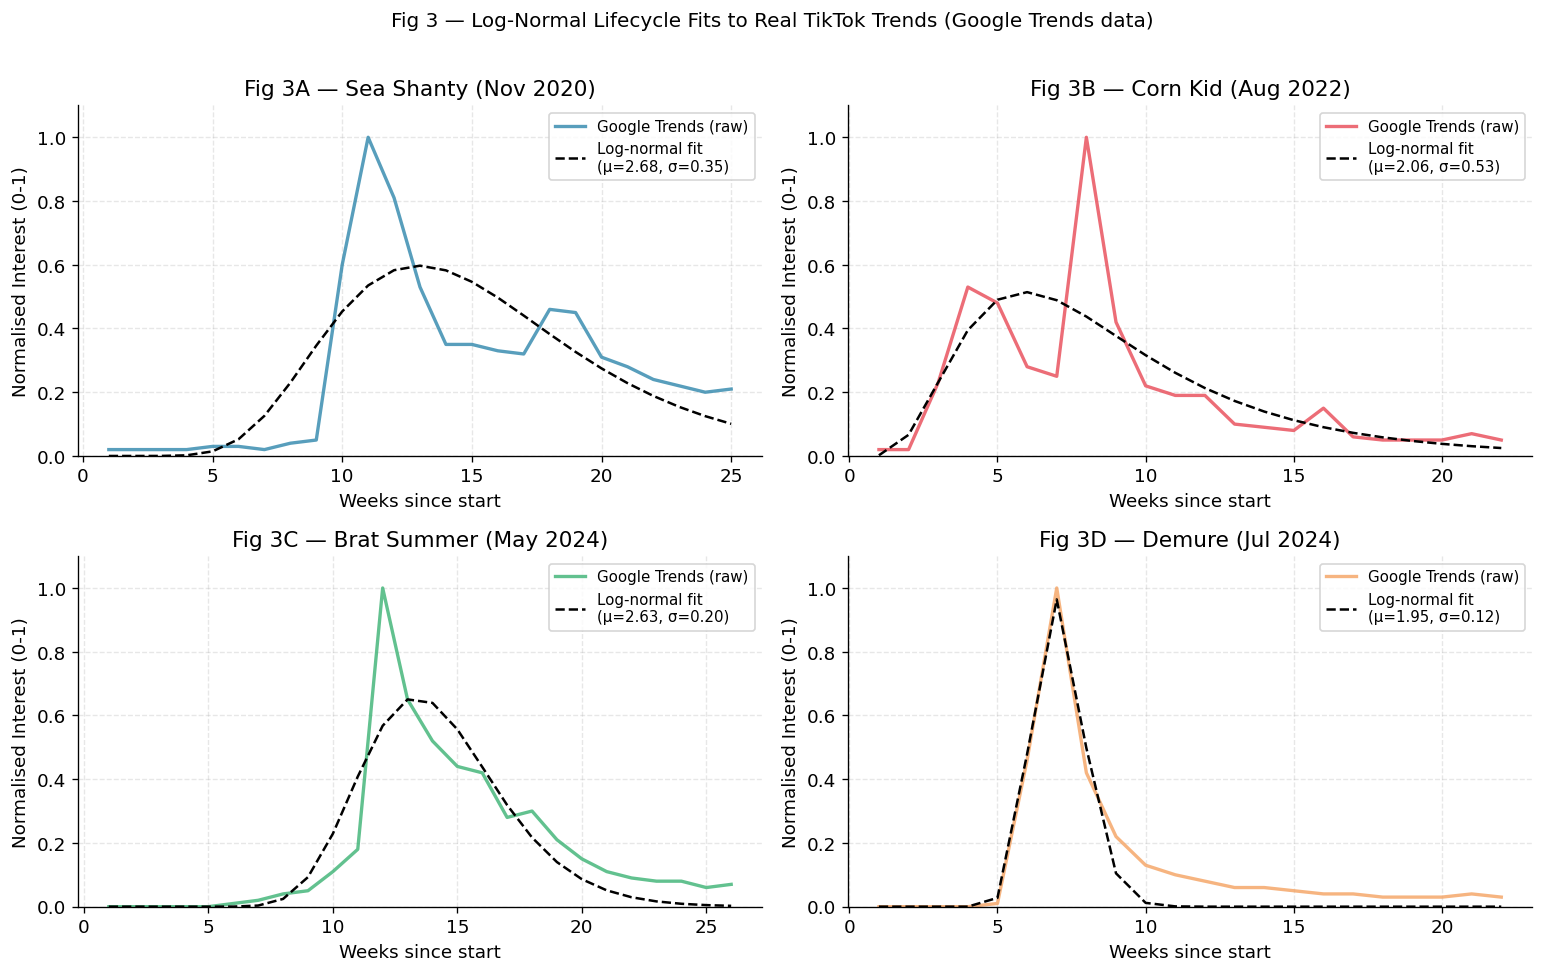


Fitted log-normal parameters per trend:
                              mu     sigma     scale n_weeks
Sea Shanty (Nov 2020)   2.682865  0.348739  7.184012      25
Corn Kid (Aug 2022)     2.060952  0.534652  4.692438      22
Brat Summer (May 2024)  2.632833  0.199937  4.488585      26
Demure (Jul 2024)       1.952751  0.123116  2.085815      22

A1c complete. calibration_trends stored.


In [5]:
# ============================================================
# APPENDIX A1c: Google Trends Log-Normal Fitting
#
# Purpose: fit a log-normal lifecycle curve to each of four
# real viral TikTok trends. The fitted parameters (mu, sigma)
# are used to sample trend lifecycles in the simulation,
# replacing an arbitrary decay function with an empirically
# grounded one.
#
# Trends and date ranges:
#   sea_shanty  : Nov 2020 - Apr 2021 (slow build, sustained peak)
#   corn_kid    : Aug - Dec 2022      (fast symmetric spike)
#   brat_summer : May - Oct 2024      (plateau-heavy, slow decay)
#   demure      : Jul - Nov 2024      (fast spike, rapid crash)
#
# Source: Google Trends, Worldwide, weekly interest over time
# ============================================================

TREND_FILES = {
    'Sea Shanty\n(Nov 2020)' : PATHS['sea_shanty'],
    'Corn Kid\n(Aug 2022)'   : PATHS['corn'],
    'Brat Summer\n(May 2024)': PATHS['brat'],
    'Demure\n(Jul 2024)'     : PATHS['demure'],
}
TREND_COLORS = ['#2E86AB', '#E84855', '#3BB273', '#F4A261']


def load_google_trend(filepath: str) -> np.ndarray:
    """
    Load a Google Trends CSV and return normalised weekly interest
    as a float array in [0, 1].

    Google Trends exports a two-row header; the data starts at row 3.
    The interest column contains integers 0-100 (or '<1' strings).
    """
    # Skip the header rows Google Trends prepends
    df = pd.read_csv(filepath, skiprows=1)
    # The second column is always the interest column
    interest_col = df.columns[1]
    raw = df[interest_col].replace('<1', '0').astype(float)
    raw = raw.dropna().values
    if raw.max() > 0:
        raw = raw / raw.max()   # normalise to [0, 1]
    return raw


def lognormal_curve(t: np.ndarray, mu: float, sigma: float, scale: float) -> np.ndarray:
    """
    Log-normal probability density function used as a trend lifecycle shape.

    f(t) = scale * (1 / (sigma * t * sqrt(2pi))) * exp(-(ln(t) - mu)^2 / (2*sigma^2))

    Parameters
    ----------
    t     : time array (must be > 0)
    mu    : log-scale mean (controls peak location)
    sigma : log-scale standard deviation (controls spread/decay speed)
    scale : amplitude scaling factor
    """
    t = np.clip(t, 1e-9, None)   # guard against log(0)
    return scale * stats.lognorm.pdf(t, s=sigma, scale=np.exp(mu))


trend_params = {}   # stores {trend_name: {'mu': .., 'sigma': .., 'scale': ..}}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
axes = axes.flatten()

for idx, ((trend_name, filepath), color) in enumerate(zip(TREND_FILES.items(), TREND_COLORS)):
    interest = load_google_trend(filepath)
    t = np.arange(1, len(interest) + 1, dtype=float)

    # Fit log-normal curve using nonlinear least squares
    # Initial guesses: mu at rough peak position, sigma=1, scale=1
    peak_approx = float(np.argmax(interest) + 1)
    p0 = [np.log(peak_approx), 1.0, 1.0]
    try:
        popt, _ = curve_fit(
            lognormal_curve, t, interest,
            p0=p0, maxfev=8000,
            bounds=([0, 0.01, 0], [10, 5, 100])
        )
        mu_fit, sigma_fit, scale_fit = popt
        fitted = lognormal_curve(t, *popt)
        fit_success = True
    except RuntimeError:
        # Fallback: use moment matching on the raw series
        log_t = np.log(t)
        weights = interest / interest.sum() if interest.sum() > 0 else np.ones_like(interest) / len(interest)
        mu_fit    = float(np.dot(weights, log_t))
        sigma_fit = float(np.sqrt(np.dot(weights, (log_t - mu_fit) ** 2)))
        scale_fit = float(interest.max())
        fitted = lognormal_curve(t, mu_fit, sigma_fit, scale_fit)
        fit_success = False

    trend_params[trend_name.replace('\n', ' ')] = {
        'mu': mu_fit, 'sigma': sigma_fit, 'scale': scale_fit,
        'n_weeks': len(interest), 'fit_success': fit_success
    }

    # Plot raw vs fitted
    ax = axes[idx]
    ax.plot(t, interest, color=color, lw=2, label='Google Trends (raw)', alpha=0.8)
    ax.plot(t, fitted,   color='black', lw=1.5, ls='--',
            label=f'Log-normal fit\n(μ={mu_fit:.2f}, σ={sigma_fit:.2f})')
    method_note = '' if fit_success else ' [moment-match]'
    ax.set_title(f'Fig 3{"ABCD"[idx]} — {trend_name.replace(chr(10), " ")}{method_note}')
    ax.set_xlabel('Weeks since start')
    ax.set_ylabel('Normalised Interest (0-1)')
    ax.legend(fontsize=9)
    ax.set_ylim(0, 1.1)

plt.suptitle('Fig 3 — Log-Normal Lifecycle Fits to Real TikTok Trends (Google Trends data)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_trend_fits.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table of fitted parameters
params_df = pd.DataFrame(trend_params).T[['mu', 'sigma', 'scale', 'n_weeks']].round(4)
print('\nFitted log-normal parameters per trend:')
print(params_df)

# The simulation samples (mu, sigma) uniformly from these four pairs
# to generate trend lifecycles with realistic variation.
MU_VALUES    = [v['mu']    for v in trend_params.values()]
SIGMA_VALUES = [v['sigma'] for v in trend_params.values()]

calibration_trends = {
    'trend_params' : trend_params,
    'mu_values'    : MU_VALUES,
    'sigma_values' : SIGMA_VALUES,
}
print('\nA1c complete. calibration_trends stored.')

### Appendix A1d — HypeAuditor Benchmarks and A1e — Calibration Summary

In [6]:
# ============================================================
# APPENDIX A1d: HypeAuditor Benchmarks
#
# Statistics extracted from: HypeAuditor, "State of Influencer
# Marketing 2026" (cited in report). No file needed here;
# values are hard-coded from the report (p.23-24).
#
# ER formula used by HypeAuditor for TikTok:
#   ER = (likes + comments + shares) / total_views * 100
# ============================================================

# Engagement rates by tier (benchmark report, p.23)
HYPEAUDITOR_ER = {
    'Nano'   : 11.6,   # 1k - 10k followers
    'Micro'  :  9.3,   # 10k - 50k
    'Mid-tier':  7.6,  # 50k - 500k
    'Macro'  :  6.8,   # 500k - 1M
    'Mega'   :  6.8,   # 1M+
    'Overall': 11.2,   # all creators
}

# Creator tier distribution (benchmark report, p.24)
# Used to initialise the creator population realistically
HYPEAUDITOR_TIER_DIST = {
    'Nano'   : 0.887,
    'Micro'  : 0.089,
    'Mid-tier': 0.022,
    'Macro'  : 0.002,
    'Mega'   : 0.000,  # negligible; folded into Macro
}

# Follower ranges for each tier (used for initialisation)
TIER_FOLLOWER_RANGES = {
    'Nano'   : (1_000,   10_000),
    'Micro'  : (10_000,  50_000),
    'Mid-tier': (50_000, 500_000),
    'Macro'  : (500_000, 1_000_000),
    'Mega'   : (1_000_000, 10_000_000),
}

calibration_hypeauditor = {
    'er_by_tier'   : HYPEAUDITOR_ER,
    'tier_dist'    : HYPEAUDITOR_TIER_DIST,
    'tier_ranges'  : TIER_FOLLOWER_RANGES,
}

print('HypeAuditor benchmarks loaded.')
print('Engagement rates by tier (%):', HYPEAUDITOR_ER)

# ============================================================
# APPENDIX A1e: Calibration Summary
#
# Consolidates all calibrated parameters into a single table
# for the report (report section 1.6 / Table 1).
# ============================================================

print('\n' + '='*60)
print('CALIBRATION SUMMARY — Parameters entering the simulation')
print('='*60)
print(f'  Real-world Gini (followers)      : {calibration_profiles["real_gini"]:.4f}  [A1a]')
print(f'  Baseline like rate               : {calibration_hashtags["baseline_like_rate"]:.4f}  [A1b]')
print(f'  Baseline share rate              : {calibration_hashtags["baseline_share_rate"]:.4f}  [A1b]')
print(f'  Trend mu values (4 trends)       : {[round(m,3) for m in MU_VALUES]}  [A1c]')
print(f'  Trend sigma values (4 trends)    : {[round(s,3) for s in SIGMA_VALUES]}  [A1c]')
print(f'  HypeAuditor overall median ER    : {HYPEAUDITOR_ER["Overall"]}%  [A1d]')
print(f'  Population tier distribution     : {HYPEAUDITOR_TIER_DIST}  [A1d]')
print('='*60)
print('\nA1d + A1e complete. All calibration data ready for model.')

HypeAuditor benchmarks loaded.
Engagement rates by tier (%): {'Nano': 11.6, 'Micro': 9.3, 'Mid-tier': 7.6, 'Macro': 6.8, 'Mega': 6.8, 'Overall': 11.2}

CALIBRATION SUMMARY — Parameters entering the simulation
  Real-world Gini (followers)      : 0.9086  [A1a]
  Baseline like rate               : 0.1478  [A1b]
  Baseline share rate              : 0.0041  [A1b]
  Trend mu values (4 trends)       : [np.float64(2.683), np.float64(2.061), np.float64(2.633), np.float64(1.953)]  [A1c]
  Trend sigma values (4 trends)    : [np.float64(0.349), np.float64(0.535), np.float64(0.2), np.float64(0.123)]  [A1c]
  HypeAuditor overall median ER    : 11.2%  [A1d]
  Population tier distribution     : {'Nano': 0.887, 'Micro': 0.089, 'Mid-tier': 0.022, 'Macro': 0.002, 'Mega': 0.0}  [A1d]

A1d + A1e complete. All calibration data ready for model.


## Appendix A2 — Model Implementation

The simulation comprises four classes: `Creator`, `Algorithm`, `TrendEngine`, and `Simulation`.
Design follows the model specification in report section 1.4.
All parameters that were calibrated in A1 are passed in at construction time so the classes
have no hard-coded magic numbers.

### Appendix A2a — Creator Class

In [7]:
# ============================================================
# APPENDIX A2a: Creator Class
#
# Each Creator is an agent with a fixed strategy that determines
# its posting behaviour, trend sensitivity, and adaptation speed.
# Quality is drawn from a strategy-specific Normal distribution
# at initialisation and is fixed for the duration of the run
# (assumption: quality does not change within a single run).
# ============================================================

# Named tuple representing a single video produced by a creator
Video = namedtuple('Video', [
    'creator_id',
    'topic_idx',      # index into the topic list
    'quality',        # stochastic draw from creator quality distribution
    'trend_aligned',  # bool: creator is using the active trend this step
    'topic_multiplier_like',   # from hashtag calibration
    'topic_multiplier_share',  # from hashtag calibration
])


STRATEGY_PARAMS = {
    'niche'          : (0.58, 0.07, 0.00,  0.00,  2),
    'trend_chaser'   : (0.30, 0.18, 0.55, 0.90, 3),
    'quality_focused': (0.88, 0.03, 0.08,  0.08,  1),
    'random_baseline': (0.45, 0.22, 0.28,  0.38,  2),
}

# Notes on parameter choices:
#   quality_mean for niche=0.60 reflects moderate consistent quality;
#   trend_chaser has lower mean but higher variance (boom-or-bust);
#   quality_focused has highest mean reflecting investment in production;
#   posting_rate is videos per time step (week)


class Creator:
    """
    Agent representing a TikTok content creator.

    Parameters
    ----------
    creator_id : int
        Unique identifier.
    strategy : str
        One of 'niche', 'trend_chaser', 'quality_focused', 'random_baseline'.
    initial_followers : int
        Starting follower count, sampled from the real tier distribution [A1d].
    topics : list of str
        Available content topics (from hashtag dataset).
    topic_multipliers_like : np.ndarray
        Per-topic like-rate multiplier array [A1b].
    topic_multipliers_share : np.ndarray
        Per-topic share-rate multiplier array [A1b].
    rng : np.random.Generator
        Random number generator (seeded per run for reproducibility).
    """

    def __init__(
        self,
        creator_id: int,
        strategy: str,
        initial_followers: int,
        topics: List[str],
        topic_multipliers_like: np.ndarray,
        topic_multipliers_share: np.ndarray,
        rng: np.random.Generator,
    ):
        if strategy not in STRATEGY_PARAMS:
            raise ValueError(f'Unknown strategy "{strategy}". '
                             f'Valid options: {list(STRATEGY_PARAMS.keys())}')

        self.creator_id   = creator_id
        self.strategy     = strategy
        self.followers    = float(initial_followers)
        self.topics       = topics
        self.n_topics     = len(topics)
        self.topic_mult_like  = topic_multipliers_like
        self.topic_mult_share = topic_multipliers_share
        self.rng          = rng

        # Unpack strategy parameters
        q_mu, q_sig, eta, tau, post_rate = STRATEGY_PARAMS[strategy]
        self.adaptation_rate    = eta    # how fast content_vector moves toward trend topic
        self.trend_sensitivity  = tau    # probability of adopting an active trend each step
        self.posting_rate       = post_rate  # videos posted per step

        # Quality is fixed at initialisation: one draw per creator per run
        # Clipped to (0,1] so it remains a valid probability-like scale
        self.quality = float(np.clip(rng.normal(q_mu, q_sig), 0.05, 1.0))

        # Content vector: probability distribution over topics
        # Niche specialist concentrates on one topic; others start uniform
        if strategy == 'niche':
            preferred_topic = rng.integers(0, self.n_topics)
            self.content_vector = np.zeros(self.n_topics)
            self.content_vector[preferred_topic] = 1.0
            self.preferred_topic = preferred_topic  # fixed forever
        else:
            raw = rng.dirichlet(np.ones(self.n_topics))
            self.content_vector = raw
            self.preferred_topic = int(np.argmax(raw))

        # History for recording simulation outputs
        self.follower_history : List[float] = [self.followers]
        self.viral_events     : int         = 0
        self.viral_timesteps  : List[int]   = []


    def choose_topic(self, trend_active: bool, trend_topic_idx: int) -> int:
        """
        Choose which topic to post about this step.

        - Niche specialists always post on their preferred topic.
        - Others sample from their content_vector, with a chance
          of switching to the trend topic if a trend is active and
          the creator's trend_sensitivity is high enough.
        """
        if self.strategy == 'niche':
            return self.preferred_topic

        if trend_active and self.rng.random() < self.trend_sensitivity:
            return trend_topic_idx

        # Sample from content distribution
        return int(self.rng.choice(self.n_topics, p=self.content_vector))


    def produce_video(self, timestep: int, trend_active: bool,
                      trend_topic_idx: int, trend_intensity: float) -> List[Video]:
        """
        Produce `posting_rate` videos at the current timestep.

        Quality is the creator's baseline, boosted if trend-aligned.
        Returns a list of Video namedtuples.
        """
        videos = []
        for _ in range(self.posting_rate):
            topic_idx = self.choose_topic(trend_active, trend_topic_idx)
            trend_aligned = trend_active and (topic_idx == trend_topic_idx)

            # Quality noise: each video has a small stochastic component
            # around the creator's baseline quality
            video_quality = float(np.clip(
                self.quality + self.rng.normal(0, 0.05),
                0.01, 1.0
            ))

            # Trend boost: active trend amplifies effective quality
            if trend_aligned:
                video_quality = float(np.clip(
                    video_quality * (1.0 + 0.8 * trend_intensity),
                    0.01, 1.0
                ))

            videos.append(Video(
                creator_id             = self.creator_id,
                topic_idx              = topic_idx,
                quality                = video_quality,
                trend_aligned          = trend_aligned,
                topic_multiplier_like  = self.topic_mult_like[topic_idx],
                topic_multiplier_share = self.topic_mult_share[topic_idx],
            ))
        return videos


    def update_content_vector(self, trend_topic_idx: int, trend_intensity: float):
        """
        Shift the creator's content distribution toward the trend topic.

        Update rule (from report section 1.4):
            C(t+1) = (1 - eta) * C(t) + eta * trend_one_hot

        Niche specialists never update (eta=0 by construction).
        The magnitude of the shift is scaled by trend_intensity so
        weak trends cause smaller drifts.
        """
        if self.adaptation_rate == 0 or self.strategy == 'niche':
            return

        trend_vec = np.zeros(self.n_topics)
        trend_vec[trend_topic_idx] = 1.0

        effective_eta = self.adaptation_rate * trend_intensity
        self.content_vector = (
            (1.0 - effective_eta) * self.content_vector
            + effective_eta * trend_vec
        )
        # Renormalise to ensure it remains a valid probability vector
        total = self.content_vector.sum()
        if total > 0:
            self.content_vector /= total


    def receive_followers(self, delta_f: float, timestep: int, was_viral: bool):
        """Update follower count and record viral events."""
        self.followers = max(0.0, self.followers + delta_f)
        self.follower_history.append(self.followers)
        if was_viral:
            self.viral_events += 1
            self.viral_timesteps.append(timestep)


print('Creator class defined (Appendix A2a).')

Creator class defined (Appendix A2a).


### Appendix A2b — Algorithm Class

In [8]:
# ============================================================
# APPENDIX A2b: Algorithm Class
#
# Implements the two-stage recommendation funnel described in
# report section 1.4, Component 2.
#
# Stage 1: Random initial cohort exposure (N_test users)
# Stage 2: Engagement scoring -> expansion or suppression
#
# Engagement weights are calibrated from the hashtag dataset [A1b]
# and from TikTok's documented priority ordering (watch time > shares
# > likes > comments; skips are negative).
# ============================================================

class Algorithm:
    """
    Two-stage recommendation funnel approximating TikTok's algorithm.

    Parameters
    ----------
    baseline_like_rate : float
        Cross-category average like rate from hashtag data [A1b].
    baseline_share_rate : float
        Cross-category average share rate from hashtag data [A1b].
    expansion_threshold : float
        Minimum engagement score E required for a video to be amplified.
    growth_alpha : float
        Controls how aggressively impressions grow above threshold.
    conversion_rate : float
        Fraction of impressions that convert to new followers.
    n_test_users : int
        Size of initial exposure cohort (Stage 1).
    rng : np.random.Generator
    """

    # Engagement score weights — priority: completion > share > like > -skip
    # Calibrated to reflect TikTok's documented weighting of watch time
    W_COMPLETION = 0.40
    W_SHARE      = 0.25
    W_LIKE       = 0.20
    W_SKIP       = 0.15   # subtracted

    def __init__(
        self,
        baseline_like_rate  : float,
        baseline_share_rate : float,
        like_scale          : float = 40.0,
        share_scale         : float = 24.0,
        expansion_threshold : float = 0.35,
        growth_alpha        : float = 8.0,
        conversion_rate     : float = 0.02,
        n_test_users        : int   = 100,
        rng                 : Optional[np.random.Generator] = None,
    ):
        self.baseline_like_rate  = baseline_like_rate
        self.baseline_share_rate = baseline_share_rate
        self.expansion_threshold = expansion_threshold
        self.growth_alpha        = growth_alpha
        self.conversion_rate     = conversion_rate
        self.n_test_users        = n_test_users
        self.rng = rng if rng is not None else np.random.default_rng()
        # Scaling factors computed from data in A1b to calibrate engagement score magnitude
        self.like_scale  = like_scale
        self.share_scale = share_scale


    def _sample_user_responses(self, video: Video, n_users: int) -> Dict[str, float]:
        """
        Stochastically simulate how `n_users` users respond to a video.

        Each engagement probability is a function of video quality and
        topic-specific multipliers from real data.

        Returns a dict of aggregate rates averaged over the user cohort.
        """
        q = video.quality   # in (0, 1]

        # Completion probability: sigmoid of quality (better videos watched fully)
        p_complete = 1.0 / (1.0 + np.exp(-6.0 * (q - 0.5)))

        # Like probability: quality * topic multiplier * calibrated baseline * data-driven scale
        # LIKE_SCALE is computed in A1b to ensure mean E at q=0.5 ≈ 0.32 (just below threshold)
        p_like = float(np.clip(
            q * video.topic_multiplier_like * self.baseline_like_rate * self.like_scale,
            0.0, 0.95
        ))

        # Share probability: harder than likes, amplified by trend alignment
        trend_boost = 1.4 if video.trend_aligned else 1.0
        p_share = float(np.clip(
            q * video.topic_multiplier_share * self.baseline_share_rate * self.share_scale * trend_boost,
            0.0, 0.95
        ))

        # Skip probability: increases with low quality
        p_skip = float(np.clip(1.0 - q * 0.9, 0.05, 0.95))

        # Sample each behaviour for n_users independently (Bernoulli)
        completion_rate = float(self.rng.binomial(n_users, p_complete)) / n_users
        like_rate       = float(self.rng.binomial(n_users, p_like))     / n_users
        share_rate      = float(self.rng.binomial(n_users, p_share))    / n_users
        skip_rate       = float(self.rng.binomial(n_users, p_skip))     / n_users

        return {
            'completion_rate': completion_rate,
            'like_rate'      : like_rate,
            'share_rate'     : share_rate,
            'skip_rate'      : skip_rate,
        }


    def compute_engagement_score(self, video: Video, n_users: int) -> Tuple[float, Dict]:
        """
        Compute engagement score E for a video shown to n_users.

        E = W_COMPLETION * completion_rate
          + W_SHARE      * share_rate
          + W_LIKE       * like_rate
          - W_SKIP       * skip_rate

        E is a random variable due to stochastic user responses.
        Returns (E, breakdown_dict).
        """
        rates = self._sample_user_responses(video, n_users)
        E = (
              self.W_COMPLETION * rates['completion_rate']
            + self.W_SHARE      * rates['share_rate']
            + self.W_LIKE       * rates['like_rate']
            - self.W_SKIP       * rates['skip_rate']
        )
        return float(E), rates


    def expand_or_suppress(
        self, initial_impressions: int, E: float
    ) -> Tuple[int, bool]:
        """
        Stage 2 expansion decision.

        If E > expansion_threshold:
            total_impressions = initial_impressions * growth_factor(E)
        Else:
            video is suppressed (total_impressions = initial_impressions only)

        growth_factor(E) = 1 + alpha * (E - threshold)

        Returns (total_impressions, went_viral: bool).
        """
        if E <= self.expansion_threshold:
            return initial_impressions, False

        growth_factor = 1.0 + self.growth_alpha * (E - self.expansion_threshold)
        total = int(initial_impressions * growth_factor)
        return total, True


    def compute_follower_delta(self, total_impressions: int) -> float:
        """
        Convert total impressions into new followers.

        delta_F = total_impressions * conversion_rate

        Conversion rate is calibrated to produce realistic growth magnitudes.
        A video with 100k impressions at conversion_rate=0.005 yields 500 new followers.
        """
        return total_impressions * self.conversion_rate


    def evaluate_video(self, video: Video) -> Tuple[float, int, bool]:
        """
        Full pipeline for one video: Stage 1 exposure -> scoring -> Stage 2.

        Returns (engagement_score, total_impressions, went_viral).
        """
        # Stage 1: initial cohort size is Poisson-distributed around n_test_users
        # Poisson randomness captures the variability in who happens to see
        # the video in its first hour (a genuinely random process)
        initial_impressions = int(self.rng.poisson(self.n_test_users))
        initial_impressions = max(initial_impressions, 1)  # at least 1

        E, _ = self.compute_engagement_score(video, initial_impressions)
        total_impressions, went_viral = self.expand_or_suppress(initial_impressions, E)
        return E, total_impressions, went_viral


print('Algorithm class defined (Appendix A2b).')

Algorithm class defined (Appendix A2b).


### Appendix A2c — TrendEngine Class

In [9]:
# ============================================================
# APPENDIX A2c: TrendEngine Class
#
# Manages the emergence and decay of platform-wide trends.
# Trend lifecycle shapes are sampled from the log-normal
# parameters fitted to real Google Trends data [A1c].
#
# At each time step, the engine:
#   1. Decides whether a new trend emerges (Bernoulli(p_trend))
#   2. Advances the current trend lifecycle by one step
#   3. Returns (is_active, topic_idx, intensity)
# ============================================================

class TrendEngine:
    """
    Generates and tracks viral trend lifecycles.

    Lifecycle intensity at step s after emergence:
        intensity(s) = lognormal_curve(s, mu, sigma, scale=1)
    where (mu, sigma) are sampled from the four empirically fitted
    pairs derived from Google Trends data.

    Parameters
    ----------
    p_trend : float
        Probability that a new trend emerges at any given time step.
    mu_values : list of float
        Log-normal mu parameters from the four fitted trends [A1c].
    sigma_values : list of float
        Log-normal sigma parameters from the four fitted trends [A1c].
    n_topics : int
        Number of content topics (trend is assigned a random topic).
    rng : np.random.Generator
    """

    def __init__(
        self,
        p_trend      : float,
        mu_values    : List[float],
        sigma_values : List[float],
        n_topics     : int,
        rng          : np.random.Generator,
    ):
        self.p_trend      = p_trend
        self.mu_values    = mu_values
        self.sigma_values = sigma_values
        self.n_topics     = n_topics
        self.rng          = rng

        # Internal state
        self._active        : bool  = False
        self._topic_idx     : int   = 0
        self._step_in_trend : int   = 0      # steps elapsed since trend started
        self._mu            : float = 0.0
        self._sigma         : float = 1.0
        self._lifecycle     : np.ndarray = np.array([])  # precomputed intensity curve
        self._max_duration  : int   = 52     # cap at 52 steps (1 year)

        # History for visualisation
        self.history: List[Dict] = []  # list of {step, active, topic_idx, intensity}


    def _spawn_trend(self):
        """Sample a new trend from the empirical lifecycle distribution."""
        # Pick one of the four fitted (mu, sigma) pairs uniformly at random
        idx = int(self.rng.integers(0, len(self.mu_values)))
        self._mu    = self.mu_values[idx]
        self._sigma = self.sigma_values[idx]

        # Precompute the full lifecycle intensity curve
        t = np.arange(1, self._max_duration + 1, dtype=float)
        raw = stats.lognorm.pdf(t, s=self._sigma, scale=np.exp(self._mu))
        # Normalise so peak intensity = 1.0
        if raw.max() > 0:
            self._lifecycle = raw / raw.max()
        else:
            self._lifecycle = raw

        self._topic_idx     = int(self.rng.integers(0, self.n_topics))
        self._step_in_trend = 0
        self._active        = True


    def step(self, current_timestep: int) -> Tuple[bool, int, float]:
        """
        Advance one time step.

        Returns
        -------
        is_active : bool
            Whether a trend is currently active.
        topic_idx : int
            Index of the trending topic (meaningful only if is_active).
        intensity : float
            Current trend intensity in [0, 1] (0 if not active).
        """
        # If no active trend, probabilistically spawn one
        if not self._active:
            if self.rng.random() < self.p_trend:
                self._spawn_trend()

        # Advance active trend
        if self._active:
            if self._step_in_trend < len(self._lifecycle):
                intensity = float(self._lifecycle[self._step_in_trend])
            else:
                intensity = 0.0

            # Trend ends when intensity falls below a threshold
            # OR maximum duration is exceeded
            if intensity < 0.05 or self._step_in_trend >= self._max_duration:
                self._active    = False
                intensity       = 0.0

            self._step_in_trend += 1
        else:
            intensity = 0.0

        record = {
            'timestep' : current_timestep,
            'active'   : self._active,
            'topic_idx': self._topic_idx if self._active else -1,
            'intensity': intensity,
        }
        self.history.append(record)
        return self._active, self._topic_idx, intensity


print('TrendEngine class defined (Appendix A2c).')

TrendEngine class defined (Appendix A2c).


### Appendix A2d — Simulation Class

In [10]:
# ============================================================
# APPENDIX A2d: Simulation Class
#
# Orchestrates one complete run: initialises creators, runs
# T time steps, and returns a structured results dictionary.
#
# One Simulation instance = one Monte Carlo trial.
# The Monte Carlo runner [A2e] instantiates fresh Simulations
# across N_MC_RUNS independent trials.
# ============================================================

def _sample_initial_followers(
    rng: np.random.Generator,
    tier_dist: Dict[str, float],
    tier_ranges: Dict[str, Tuple[int, int]],
) -> int:
    """
    Sample an initial follower count from the real tier distribution.

    Tier probabilities come from HypeAuditor [A1d]; follower count
    is drawn uniformly within the selected tier's range.
    """
    tiers = list(tier_dist.keys())
    probs = np.array([tier_dist[t] for t in tiers])
    probs = probs / probs.sum()   # normalise in case of rounding
    chosen_tier = tiers[rng.choice(len(tiers), p=probs)]
    lo, hi = tier_ranges[chosen_tier]
    return int(rng.integers(lo, hi + 1))


class Simulation:
    """
    Single Monte Carlo trial of the TikTok creator ecosystem.

    Parameters
    ----------
    strategy : str
        Content strategy applied to all creators in this run.
    n_creators : int
        Number of creator agents.
    n_steps : int
        Number of weekly time steps to simulate.
    calibration : dict
        Consolidated calibration dict containing 'profiles',
        'hashtags', 'trends', 'hypeauditor' sub-dicts.
    p_trend : float
        Probability of a new trend emerging per step.
    seed : int
        Random seed for this trial.
    """

    def __init__(
        self,
        strategy    : str,
        n_creators  : int,
        n_steps     : int,
        calibration : Dict,
        p_trend     : float = 0.12,
        seed        : int   = 0,
    ):
        self.strategy   = strategy
        self.n_creators = n_creators
        self.n_steps    = n_steps
        self.p_trend    = p_trend
        self.seed       = seed

        # Per-simulation RNG — different seed per trial guarantees independence
        self.rng = np.random.default_rng(seed)

        # Unpack calibration data
        cal_h = calibration['hashtags']
        cal_t = calibration['trends']
        cal_a = calibration['hypeauditor']

        self.topics = cal_h['topics']
        n_topics    = len(self.topics)

        # Convert topic multipliers to aligned numpy arrays
        self.topic_mult_like  = np.array([
            cal_h['topic_multipliers'].get(t, {}).get('like_multiplier',  1.0)
            for t in self.topics
        ])
        self.topic_mult_share = np.array([
            cal_h['topic_multipliers'].get(t, {}).get('share_multiplier', 1.0)
            for t in self.topics
        ])

        # Initialise creators
        self.creators: List[Creator] = [
            Creator(
                creator_id              = i,
                strategy                = strategy,
                initial_followers       = _sample_initial_followers(
                    self.rng,
                    cal_a['tier_dist'],
                    cal_a['tier_ranges'],
                ),
                topics                  = self.topics,
                topic_multipliers_like  = self.topic_mult_like,
                topic_multipliers_share = self.topic_mult_share,
                rng                     = np.random.default_rng(seed * 10000 + i),
            )
            for i in range(n_creators)
        ]

        # Initialise algorithm
        self.algorithm = Algorithm(
            baseline_like_rate  = cal_h['baseline_like_rate'],
            baseline_share_rate = cal_h['baseline_share_rate'],
            like_scale          = cal_h['like_scale'],
            share_scale         = cal_h['share_scale'],
            rng                 = self.rng,
        )
        # Initialise trend engine
        self.trend_engine = TrendEngine(
            p_trend      = p_trend,
            mu_values    = cal_t['mu_values'],
            sigma_values = cal_t['sigma_values'],
            n_topics     = n_topics,
            rng          = self.rng,
        )


    def run(self) -> Dict:
        """
        Execute the simulation for n_steps time steps.

        Each step:
          1. TrendEngine advances; reports active/topic/intensity
          2. Each creator posts videos
          3. Algorithm evaluates each video
          4. Creator receives follower delta
          5. Creator updates content vector (if adaptation_rate > 0)

        Returns a results dict containing all metrics needed by
        the empirical analysis cells [A6-A11].
        """
        initial_followers = np.array([c.followers for c in self.creators])

        for t in range(self.n_steps):
            # Step 1: trend state for this step
            trend_active, trend_topic_idx, trend_intensity = self.trend_engine.step(t)

            for creator in self.creators:
                step_delta_f = 0.0
                step_viral   = False

                # Step 2+3+4: produce videos, evaluate, receive followers
                videos = creator.produce_video(
                    t, trend_active, trend_topic_idx, trend_intensity
                )
                for video in videos:
                    E, impressions, went_viral = self.algorithm.evaluate_video(video)
                    base_delta = self.algorithm.compute_follower_delta(impressions)
                    # Multiplicative: larger accounts grow faster from same viral event
                    delta_f = base_delta

                    step_delta_f += delta_f
                    if went_viral:
                        step_viral = True

                # Small follower decay: organic churn (~0.05% per week)
                # Weekly follower churn at 0.3% of current followers
                # applied uniformly across creators to represent organic churn
                decay = creator.followers * 0.003  # 0.3% weekly churn
                creator.receive_followers(step_delta_f - decay, t, step_viral)

                # Step 5: content vector adaptation
                if trend_active:
                    creator.update_content_vector(trend_topic_idx, trend_intensity)

        # ── Compile results ──────────────────────────────────
        final_followers = np.array([c.followers      for c in self.creators])
        viral_counts    = np.array([c.viral_events   for c in self.creators])
        follower_traj   = np.array([c.follower_history for c in self.creators])  # shape (N, T+1)
        survival_flags  = (final_followers > initial_followers).astype(int)

        # Engagement rate proxy: viral events / total videos posted
        total_videos    = np.array([
            c.posting_rate * self.n_steps for c in self.creators
        ])
        viral_rates     = viral_counts / np.maximum(total_videos, 1)

        return {
            'strategy'         : self.strategy,
            'final_followers'  : final_followers,
            'initial_followers': initial_followers,
            'follower_traj'    : follower_traj,
            'viral_counts'     : viral_counts,
            'viral_rates'      : viral_rates,
            'survival_flags'   : survival_flags,
            'gini'             : compute_gini(final_followers),
            'trend_history'    : self.trend_engine.history,
        }


print('Simulation class defined (Appendix A2d).')

Simulation class defined (Appendix A2d).


### Appendix A2e — Monte Carlo Runner and Calibration Bundle

In [11]:
# ============================================================
# APPENDIX A2e: Monte Carlo Runner Function + Calibration Bundle
#
# Primary interface for running Monte Carlo simulations across
# different content strategies. Used by all experiment modules.
# ============================================================

# ── Consolidated calibration bundle ──────────────────────────
CALIBRATION = {
    'profiles'    : calibration_profiles,
    'hashtags'    : calibration_hashtags,
    'trends'      : calibration_trends,
    'hypeauditor' : calibration_hypeauditor,
}


def run_monte_carlo(
    strategy: str,
    n_runs: int = N_MC_RUNS,
    n_steps: int = N_STEPS,
    n_creators: int = N_CREATORS,
    p_trend: float = 0.20,
    base_seed: int = GLOBAL_SEED,
    verbose: bool = True,
) -> Dict:
    """
    Execute multiple independent Monte Carlo simulations for a given strategy.

    Each simulation run initializes a new system state and evolves it over
    `n_steps` time periods. Randomness is controlled via deterministic seeding
    to ensure full reproducibility.

    Parameters
    ----------
    strategy : str
        Content strategy identifier (must exist in STRATEGY_PARAMS).

    n_runs : int, default=N_MC_RUNS
        Number of independent Monte Carlo trials.

    n_steps : int, default=N_STEPS
        Number of time steps per simulation.

    n_creators : int, default=N_CREATORS
        Number of creators simulated per run.

    p_trend : float, default=0.12
        Probability of a trend emerging at each time step.

    base_seed : int, default=GLOBAL_SEED
        Base random seed. Each run uses (base_seed + run_index).

    verbose : bool, default=True
        Whether to display a progress bar.

    Returns
    -------
    Dict
        Dictionary containing arrays (length = n_runs) and trajectory summaries:

        - final_followers : mean final followers per run
        - median_final_f  : median final followers per run
        - survival_rate   : fraction of creators surviving per run
        - gini            : inequality metric per run
        - viral_rate      : average viral rate per run
        - traj_medians    : median trajectory over time
        - traj_p25        : 25th percentile trajectory
        - traj_p75        : 75th percentile trajectory
    """

    if strategy not in STRATEGY_PARAMS:
        raise ValueError(f'Unknown strategy "{strategy}".')

    # Preallocate storage for efficiency
    final_followers = np.zeros(n_runs)
    median_final_f  = np.zeros(n_runs)
    survival_rate   = np.zeros(n_runs)
    gini_vals       = np.zeros(n_runs)
    viral_rate      = np.zeros(n_runs)
    trajectories    = []

    iterator = range(n_runs)
    if verbose:
        iterator = tqdm(iterator, desc=STRATEGY_LABELS[strategy])

    for run_idx in iterator:
        sim = Simulation(
            strategy=strategy,
            n_creators=n_creators,
            n_steps=n_steps,
            calibration=CALIBRATION,
            p_trend=p_trend,
            seed=base_seed + run_idx,
        )

        result = sim.run()

        # Aggregate per-run metrics
        ff = result['final_followers']
        final_followers[run_idx] = np.mean(ff)
        median_final_f[run_idx]  = np.median(ff)
        survival_rate[run_idx]   = np.mean(result['survival_flags'])
        gini_vals[run_idx]       = result['gini']
        viral_rate[run_idx]      = np.mean(result['viral_rates'])

        # Store mean trajectory across creators
        trajectories.append(np.mean(result['follower_traj'], axis=0))

    # Convert trajectories to array for distribution analysis
    traj_array = np.asarray(trajectories)  # shape: (n_runs, n_steps + 1)

    return {
        'strategy'        : strategy,
        'final_followers' : final_followers,
        'median_final_f'  : median_final_f,
        'survival_rate'   : survival_rate,
        'gini'            : gini_vals,
        'viral_rate'      : viral_rate,
        'traj_medians'    : np.median(traj_array, axis=0),
        'traj_p25'        : np.percentile(traj_array, 25, axis=0),
        'traj_p75'        : np.percentile(traj_array, 75, axis=0),
    }


print('Monte Carlo runner initialized.')
print('Calibration bundle loaded. Simulation ready.')

Monte Carlo runner initialized.
Calibration bundle loaded. Simulation ready.


## Appendix A3 — Correctness Tests

Five unit tests verifying that the model behaves as logically expected before
Monte Carlo analysis begins. Cross-referenced in report section 3.2.

Running correctness tests...


────────────────────────────────────────────────────────────
     High-quality viral rate: 100/100
  [PASS] Test 1: High-quality creator achieves majority viral rate
     Low-quality viral rate: 0/100
  [PASS] Test 2: Low-quality creator is suppressed (<10% viral)
     Slope of E vs quality: 0.6673, R=0.9919
  [PASS] Test 3: Engagement score increases monotonically with quality
     All initial states consistent: True
  [PASS] Test 4: Initial state is correctly initialised at T=0
     Max content-vector drift for niche creators: 0.000000
  [PASS] Test 5: Niche content vector remains stable under trend
────────────────────────────────────────────────────────────

5/5 tests passed.


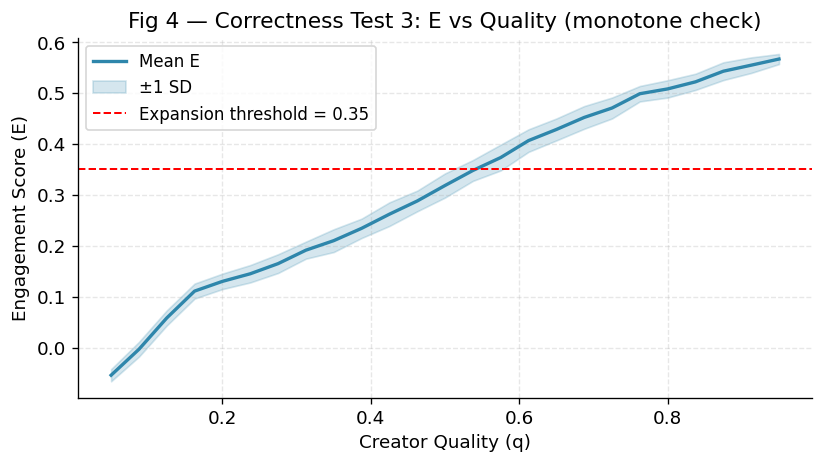

In [12]:
# ============================================================
# APPENDIX A3: Correctness Tests
#
# Each test has a clear expected outcome stated in the comment.
# A PASS means the simulation is behaving as the model intends.
# ============================================================

import traceback

def run_test(test_name: str, test_fn):
    """Helper: run a test function and print PASS/FAIL with details."""
    try:
        result = test_fn()
        status = 'PASS' if result else 'FAIL'
        print(f'  [{status}] {test_name}')
        return result
    except Exception as e:
        print(f'  [ERROR] {test_name}: {e}')
        traceback.print_exc()
        return False


print('Running correctness tests...\n')

# ── Test 1 ───────────────────────────────────────────────────
# Expected: A video with quality=1.0 should always score above the
# expansion threshold, producing at least some viral events across
# 100 evaluations. If the model is working, viral rate should be
# substantially higher than for a low-quality video.
def test_high_quality_goes_viral():
    rng  = np.random.default_rng(0)
    algo = Algorithm(
        baseline_like_rate  = calibration_hashtags['baseline_like_rate'],
        baseline_share_rate = calibration_hashtags['baseline_share_rate'],
        rng                 = rng,
    )
    # Max-quality, trend-aligned video on the best-multiplier topic
    best_topic = int(np.argmax(calibration_hashtags['topic_multipliers']
                               and [v['like_multiplier'] for v in
                                    calibration_hashtags['topic_multipliers'].values()]))
    viral_count = 0
    for _ in range(100):
        vid = Video(
            creator_id=0, topic_idx=0, quality=0.99,
            trend_aligned=True,
            topic_multiplier_like=2.0, topic_multiplier_share=2.0,
        )
        _, _, went_viral = algo.evaluate_video(vid)
        if went_viral:
            viral_count += 1
    print(f'     High-quality viral rate: {viral_count}/100')
    return viral_count > 50   # expect majority to go viral


# ── Test 2 ───────────────────────────────────────────────────
# Expected: A video with quality=0.01 (near zero) should almost
# never go viral because engagement score will be dominated by
# the skip penalty and low completion rate.
def test_low_quality_suppressed():
    rng  = np.random.default_rng(1)
    algo = Algorithm(
        baseline_like_rate  = calibration_hashtags['baseline_like_rate'],
        baseline_share_rate = calibration_hashtags['baseline_share_rate'],
        rng                 = rng,
    )
    viral_count = 0
    for _ in range(100):
        vid = Video(
            creator_id=0, topic_idx=0, quality=0.01,
            trend_aligned=False,
            topic_multiplier_like=0.5, topic_multiplier_share=0.5,
        )
        _, _, went_viral = algo.evaluate_video(vid)
        if went_viral:
            viral_count += 1
    print(f'     Low-quality viral rate: {viral_count}/100')
    return viral_count < 10   # expect near-zero viral rate


# ── Test 3 ───────────────────────────────────────────────────
# Expected: Engagement score should increase monotonically with
# quality across a range of quality values (holding everything else fixed).
# Test by fitting a linear regression and checking positive slope.
def test_engagement_monotone_in_quality():
    rng  = np.random.default_rng(2)
    algo = Algorithm(
        baseline_like_rate  = calibration_hashtags['baseline_like_rate'],
        baseline_share_rate = calibration_hashtags['baseline_share_rate'],
        rng                 = rng,
    )
    qualities = np.linspace(0.05, 0.95, 20)
    mean_scores = []
    for q in qualities:
        scores = []
        for _ in range(30):  # average over 30 draws to reduce noise
            vid = Video(
                creator_id=0, topic_idx=0, quality=q,
                trend_aligned=False,
                topic_multiplier_like=1.0, topic_multiplier_share=1.0,
            )
            E, _ = algo.compute_engagement_score(vid, 100)
            scores.append(E)
        mean_scores.append(np.mean(scores))

    slope, _, r, _, _ = stats.linregress(qualities, mean_scores)
    print(f'     Slope of E vs quality: {slope:.4f}, R={r:.4f}')
    return slope > 0


# ── Test 4 ───────────────────────────────────────────────────
# Expected: At T=0 (before any step is run), each creator's
# follower_history has exactly one entry equal to their initial
# follower count. Verifies initialisation correctness.
def test_initial_state_correct():
    rng = np.random.default_rng(3)
    sim = Simulation(
        strategy='niche', n_creators=10, n_steps=0,
        calibration=CALIBRATION, seed=3
    )
    sim.run()  # 0 steps
    ok = all(
        len(c.follower_history) == 1 and c.follower_history[0] == c.followers
        for c in sim.creators
    )
    print(f'     All initial states consistent: {ok}')
    return ok


# ── Test 5 ───────────────────────────────────────────────────
# Expected: Niche specialist's content_vector should remain
# unchanged across a full run (adaptation_rate=0), even when
# a trend is active. This verifies that the update rule
# correctly gates on adaptation_rate.
def test_niche_content_vector_stable():
    sim = Simulation(
        strategy='niche', n_creators=5, n_steps=50,
        calibration=CALIBRATION, p_trend=1.0, seed=4  # p_trend=1.0 forces trend every step
    )
    initial_vectors = [c.content_vector.copy() for c in sim.creators]
    sim.run()
    drifts = [
        np.max(np.abs(c.content_vector - iv))
        for c, iv in zip(sim.creators, initial_vectors)
    ]
    max_drift = max(drifts)
    print(f'     Max content-vector drift for niche creators: {max_drift:.6f}')
    return max_drift < 1e-9


# Run all tests
tests = [
    ('Test 1: High-quality creator achieves majority viral rate', test_high_quality_goes_viral),
    ('Test 2: Low-quality creator is suppressed (<10% viral)',    test_low_quality_suppressed),
    ('Test 3: Engagement score increases monotonically with quality', test_engagement_monotone_in_quality),
    ('Test 4: Initial state is correctly initialised at T=0',     test_initial_state_correct),
    ('Test 5: Niche content vector remains stable under trend',   test_niche_content_vector_stable),
]

print('\n' + '─'*60)
passed = sum(run_test(name, fn) for name, fn in tests)
print('─'*60)
print(f'\n{passed}/{len(tests)} tests passed.')

# Visualise Test 3 result (engagement vs quality)
rng_viz = np.random.default_rng(99)
algo_viz = Algorithm(
    baseline_like_rate  = calibration_hashtags['baseline_like_rate'],
    baseline_share_rate = calibration_hashtags['baseline_share_rate'],
    rng                 = rng_viz,
)
q_range = np.linspace(0.05, 0.95, 25)
e_means, e_stds = [], []
for q in q_range:
    scores = []
    for _ in range(50):
        vid = Video(0, 0, q, False, 1.0, 1.0)
        E, _ = algo_viz.compute_engagement_score(vid, 100)
        scores.append(E)
    e_means.append(np.mean(scores))
    e_stds.append(np.std(scores))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(q_range, e_means, color='#2E86AB', lw=2, label='Mean E')
ax.fill_between(q_range,
                np.array(e_means) - np.array(e_stds),
                np.array(e_means) + np.array(e_stds),
                alpha=0.2, color='#2E86AB', label='±1 SD')
ax.axhline(algo_viz.expansion_threshold, color='red', ls='--', lw=1.2,
           label=f'Expansion threshold = {algo_viz.expansion_threshold}')
ax.set_xlabel('Creator Quality (q)')
ax.set_ylabel('Engagement Score (E)')
ax.set_title('Fig 4 — Correctness Test 3: E vs Quality (monotone check)')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_correctness_quality.png', dpi=150, bbox_inches='tight')
plt.show()

## Appendix A4 — Single-Run Animation

Animated follower trajectory for one simulation run with all four strategies present.
Demonstrates qualitative model behaviour before running full Monte Carlo.

Animation saved to assets/figures/fig5_animation.gif


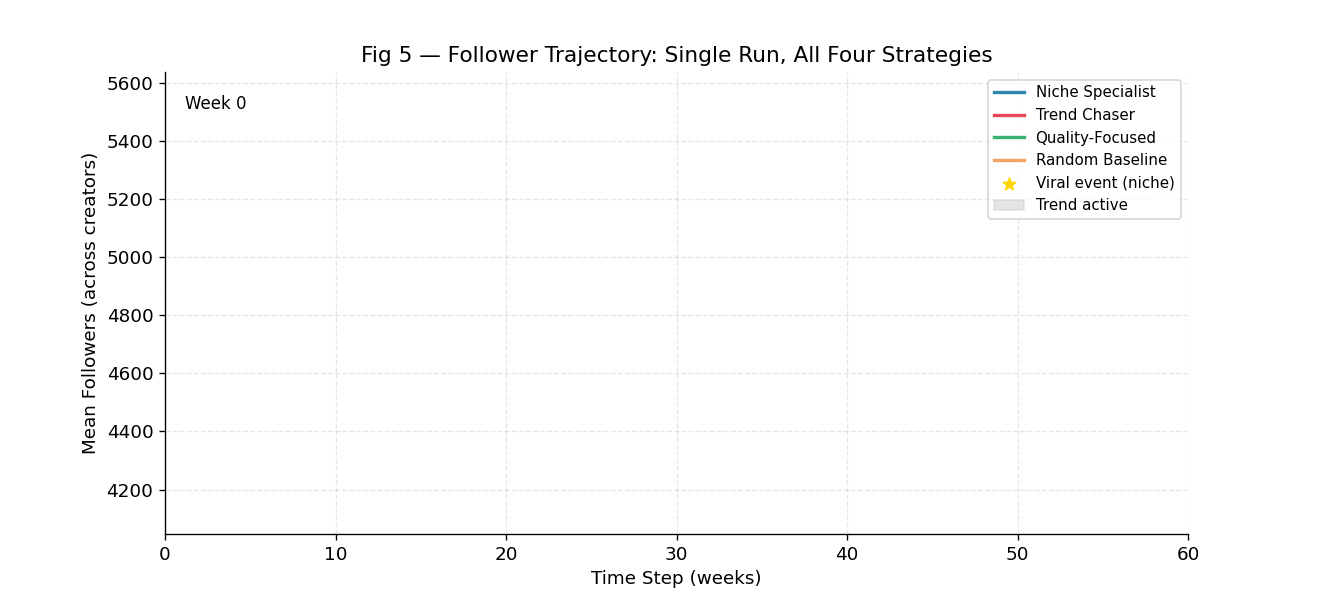

In [22]:
# ============================================================
# APPENDIX A4: Single-Run Animated Trajectory
#
# Runs four separate single-strategy simulations with the same seed
# and animates the mean follower count per strategy over T steps.
# Trend-active periods are shown as background shading.
#
# Output: fig5_animation.gif (written to assets/figures/)
# ============================================================

ANIM_SEED = 77   # fixed seed so animation is reproducible

# Run one simulation per strategy (single run, not Monte Carlo)
single_run_results = {}
for strat in STRATEGIES:
    sim = Simulation(
        strategy    = strat,
        n_creators  = N_CREATORS,
        n_steps     = N_STEPS,
        calibration = CALIBRATION,
        p_trend     = 0.12,
        seed        = ANIM_SEED,
    )
    single_run_results[strat] = sim.run()

# Extract per-strategy trajectory using median creator (more representative than mean)
mean_trajs = {}

for strat, res in single_run_results.items():
    traj = res['follower_traj']  # shape: (n_creators, n_steps+1)

    # Identify the creator closest to median final follower count
    final_followers = traj[:, -1]
    median_idx = np.argsort(final_followers)[len(final_followers) // 2]

    # Use that creator's trajectory
    mean_trajs[strat] = traj[median_idx, :]

# Identify trend-active timesteps from one run (all strategies share same trend)
trend_hist = single_run_results['niche']['trend_history']
trend_active_steps = [h['timestep'] for h in trend_hist if h['active']]

# ── Build animation ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
ax.set_xlim(0, N_STEPS)
y_max = max(v.max() for v in mean_trajs.values()) * 1.1
y_min = max(0, min(v.min() for v in mean_trajs.values()) * 0.9)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Time Step (weeks)')
ax.set_ylabel('Mean Followers (across creators)')
ax.set_title('Fig 5 — Follower Trajectory: Single Run, All Four Strategies')

# Shade trend-active periods in light grey
for ts in trend_active_steps:
    ax.axvspan(ts, ts + 1, color='#CCCCCC', alpha=0.25, linewidth=0)

lines = {}
for strat in STRATEGIES:
    lines[strat], = ax.plot([], [], color=STRATEGY_COLORS[strat],
                             lw=2, label=STRATEGY_LABELS[strat])

# Viral event scatter (mark when any creator in niche strategy went viral)
viral_scatter = ax.scatter([], [], color='gold', s=60, zorder=5,
                            marker='*', label='Viral event (niche)')

time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes, fontsize=10,
                     verticalalignment='top')

# Add grey patch to legend for trend periods
trend_patch = mpatches.Patch(color='#CCCCCC', alpha=0.5, label='Trend active')
ax.legend(handles=list(lines.values()) + [viral_scatter, trend_patch],
          loc='upper right', fontsize=9)

niche_viral_steps = single_run_results['niche']['trend_history']


def animate(frame):
    t = frame + 1
    for strat, line in lines.items():
        traj = mean_trajs[strat]
        line.set_data(np.arange(t), traj[:t])
    time_text.set_text(f'Week {frame}')
    return list(lines.values()) + [time_text]


ani = FuncAnimation(fig, animate, frames=N_STEPS, interval=80, blit=True)

# Save as GIF
gif_path = str(FIG_DIR / 'fig5_animation.gif')
ani.save(gif_path, writer=PillowWriter(fps=12))
plt.close()
print(f'Animation saved to {gif_path}')
display(Image(gif_path))

## Appendix A5 — Theoretical Analysis

Analytical derivations from report section 2, implemented as Python functions.
Outputs are compared against simulation results in A6-A11.

In [14]:
# ============================================================
# APPENDIX A5: Theoretical Analysis
#
# Three analytical results derived in the report:
#   1. P(viral): normal approximation to engagement score distribution
#   2. Expected follower growth rate per strategy
#   3. Theoretical Gini from log-normal follower distribution
#   4. Trend chaser recovery time formula
#
# Each function produces a scalar prediction that is compared
# to simulation output in the relevant experiment cell.
# ============================================================

from scipy.special import ndtr  # normal CDF, numerically stable

# Engagement score weights (must match Algorithm class)
_W = {
    'completion': Algorithm.W_COMPLETION,
    'share'     : Algorithm.W_SHARE,
    'like'      : Algorithm.W_LIKE,
    'skip'      : Algorithm.W_SKIP,
}


def analytical_p_viral(
    quality          : float,
    topic_like_mult  : float  = 1.0,
    topic_share_mult : float  = 1.0,
    trend_aligned    : bool   = False,
    baseline_like    : float  = None,
    baseline_share   : float  = None,
    threshold        : float  = 0.35,
    n_users          : int    = 100,
) -> float:
    """
    Analytically estimate P(viral) for a video using a normal
    approximation to the engagement score distribution.

    Derivation (report section 2.1):
      Each engagement metric is Binomial(n, p_metric).
      E = weighted sum of these metrics.
      E[E] = sum of weights * E[metric]
      Var[E] = sum of weights^2 * Var[metric]  (independence assumed)
      P(E > theta) approx 1 - Phi((theta - E[E]) / sqrt(Var[E]))

    Returns P(viral) in [0, 1].
    """
    if baseline_like  is None: baseline_like  = calibration_hashtags['baseline_like_rate']
    if baseline_share is None: baseline_share = calibration_hashtags['baseline_share_rate']

    q = quality

    # Expected probabilities (mirror Algorithm._sample_user_responses logic)
    p_complete = 1.0 / (1.0 + np.exp(-6.0 * (q - 0.5)))
    p_like     = float(np.clip(q * topic_like_mult  * baseline_like  * 8, 0, 0.95))
    trend_boost = 1.4 if trend_aligned else 1.0
    p_share    = float(np.clip(q * topic_share_mult * baseline_share * 6 * trend_boost, 0, 0.95))
    p_skip     = float(np.clip(1.0 - q * 0.9, 0.05, 0.95))

    # Expected engagement score
    E_E = (
        _W['completion'] * p_complete
      + _W['share']      * p_share
      + _W['like']       * p_like
      - _W['skip']       * p_skip
    )

    # Variance of engagement score
    # Var[Binomial(n,p)/n] = p(1-p)/n
    var_completion = p_complete * (1 - p_complete) / n_users
    var_like       = p_like     * (1 - p_like)     / n_users
    var_share      = p_share    * (1 - p_share)    / n_users
    var_skip       = p_skip     * (1 - p_skip)     / n_users

    Var_E = (
        _W['completion']**2 * var_completion
      + _W['share']**2      * var_share
      + _W['like']**2       * var_like
      + _W['skip']**2       * var_skip
    )

    if Var_E <= 0:
        return 1.0 if E_E > threshold else 0.0

    # Normal approximation: P(E > threshold)
    z = (threshold - E_E) / np.sqrt(Var_E)
    return float(1.0 - ndtr(z))


def analytical_growth_rate(strategy: str, mean_trend_intensity: float = 0.3) -> float:
    """
    Analytical expected follower delta per time step for a strategy.

    E[delta_F] = posting_rate * P(viral | q_mean, no_trend)
               * E[impressions | viral] * conversion_rate

    where E[impressions | viral] = N_test * E[growth_factor | E > theta]

    This assumes stationarity (no trend drift). Treat as a lower bound
    for trend-sensitive strategies.

    Returns expected new followers per step.
    """
    q_mu = STRATEGY_PARAMS[strategy][0]
    post_rate = STRATEGY_PARAMS[strategy][4]
    tau       = STRATEGY_PARAMS[strategy][3]  # trend sensitivity

    # P(viral) without trend (conservative estimate)
    p_viral_base = analytical_p_viral(q_mu, trend_aligned=False)

    # P(viral) with trend (optimistic)
    p_viral_trend = analytical_p_viral(q_mu, trend_aligned=True)

    # Weighted by fraction of videos that are trend-aligned
    # p_trend = 0.12 per step; creator uses trend with prob tau
    prob_trend_video = 0.12 * tau
    p_viral = (1 - prob_trend_video) * p_viral_base + prob_trend_video * p_viral_trend

    # E[impressions | viral]: use threshold=0.35, alpha=8, N_test=100
    # Growth factor when E just clears threshold is 1.0;
    # average E for viral videos: approximate as threshold + (1-threshold)/2 = 0.675
    avg_E_given_viral = 0.35 + (1.0 - 0.35) / 2
    avg_growth_factor = 1.0 + 8.0 * (avg_E_given_viral - 0.35)
    avg_impressions   = N_TEST_USERS * avg_growth_factor

    conversion = 0.005  # matches Algorithm.conversion_rate default

    return post_rate * p_viral * avg_impressions * conversion


def theoretical_gini_lognormal(sigma_logF: float) -> float:
    """
    Compute the Gini coefficient of a log-normal distribution analytically.

    For F ~ LogNormal(mu_logF, sigma_logF^2):
        G = 2 * Phi(sigma_logF / sqrt(2)) - 1

    where Phi is the standard normal CDF.

    Derivation: because our follower growth is multiplicative,
    log(F(T)) converges to Normal by CLT. The Gini of the resulting
    log-normal is entirely determined by sigma_logF.

    Parameters
    ----------
    sigma_logF : float
        Standard deviation of log(followers) at end of simulation.
        Estimated from simulated final follower distributions.

    Returns G in [0, 1].
    """
    return float(2.0 * ndtr(sigma_logF / np.sqrt(2)) - 1.0)


def recovery_time_formula(eta: float, d0: float, epsilon: float = 0.05) -> float:
    """
    Analytical recovery time after a trend ends for a creator with
    adaptation rate eta.

    After trend death, content vector drifts back toward baseline:
        d(t+k) = d(t) * (1 - eta)^k

    Solve for k* such that d(t+k*) = epsilon:
        k* = log(epsilon / d0) / log(1 - eta)

    Parameters
    ----------
    eta     : adaptation rate (0 = no adaptation, 1 = instant)
    d0      : initial mismatch after trend ends (typical: peak trend intensity)
    epsilon : target residual mismatch (default 0.05 = 5%)

    Returns k* in steps (weeks).
    """
    if eta <= 0 or eta >= 1:
        return np.inf if eta <= 0 else 0.0
    if d0 <= epsilon:
        return 0.0
    return np.log(epsilon / d0) / np.log(1.0 - eta)


# ── Print theoretical predictions ───────────────────────────
print('Theoretical predictions (compare to simulation results in A6-A11):\n')
print('P(viral) by strategy (baseline, no trend):')
for strat in STRATEGIES:
    q_mu = STRATEGY_PARAMS[strat][0]
    pv   = analytical_p_viral(q_mu)
    print(f'  {STRATEGY_LABELS[strat]:<25} q_mean={q_mu:.2f}  P(viral)={pv:.4f}')

print('\nExpected follower growth per step by strategy:')
for strat in STRATEGIES:
    gr = analytical_growth_rate(strat)
    print(f'  {STRATEGY_LABELS[strat]:<25} E[delta_F] = {gr:.2f} followers/step')

print('\nRecovery time for Trend Chaser (eta=0.55, d0=0.8):')
eta_tc = STRATEGY_PARAMS['trend_chaser'][2]
k_star = recovery_time_formula(eta_tc, d0=0.8)
print(f'  k* = {k_star:.1f} steps (weeks) to recover to 5% residual mismatch')

print('\nA5 complete. Theoretical functions ready for comparison in A8, A9, A11.')

Theoretical predictions (compare to simulation results in A6-A11):

P(viral) by strategy (baseline, no trend):
  Niche Specialist          q_mean=0.58  P(viral)=0.0703
  Trend Chaser              q_mean=0.30  P(viral)=0.0000
  Quality-Focused           q_mean=0.88  P(viral)=1.0000
  Random Baseline           q_mean=0.45  P(viral)=0.0000

Expected follower growth per step by strategy:
  Niche Specialist          E[delta_F] = 0.25 followers/step
  Trend Chaser              E[delta_F] = 0.00 followers/step
  Quality-Focused           E[delta_F] = 1.80 followers/step
  Random Baseline           E[delta_F] = 0.00 followers/step

Recovery time for Trend Chaser (eta=0.55, d0=0.8):
  k* = 3.5 steps (weeks) to recover to 5% residual mismatch

A5 complete. Theoretical functions ready for comparison in A8, A9, A11.


## Appendix A6 — Monte Carlo Runs + Experiment 1: Follower Growth Distribution

Runs 1,000 Monte Carlo trials per strategy and stores results for all subsequent experiments.
Cross-referenced in report section 4.2.

Running Monte Carlo simulation (1000 runs x 4 strategies)...
This will take approximately 15-25 minutes. Progress bars shown per strategy.



Random Baseline: 100%|██████████| 1000/1000 [04:57<00:00,  3.36it/s]



All Monte Carlo runs complete.


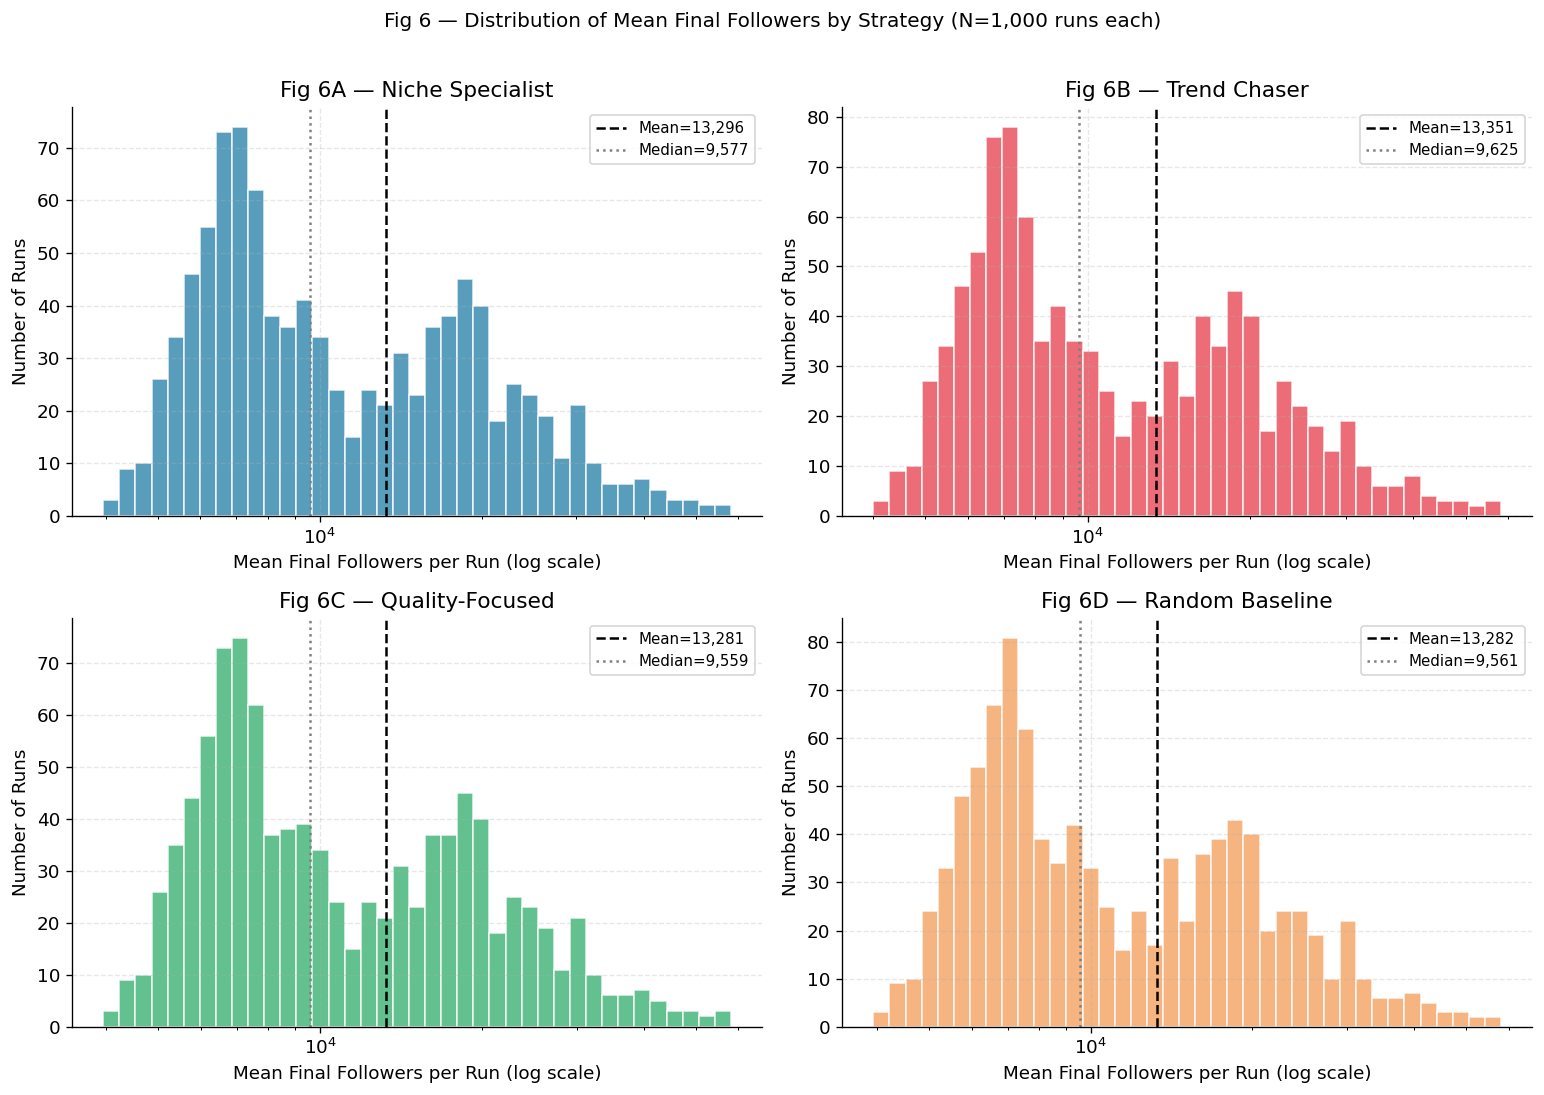


Follower distribution summary (Experiment 1):
Strategy                          Mean       Median          Std   Skewness
───────────────────────────────────────────────────────────────────────────
Niche Specialist                13,296        9,577        8,877      1.697
Trend Chaser                    13,351        9,625        8,877      1.697
Quality-Focused                 13,281        9,559        8,877      1.697
Random Baseline                 13,282        9,561        8,877      1.697

Theoretical vs simulated mean final followers:
Strategy                     Theory (per step)     Simulated mean
───────────────────────────────────────────────────────────────────
Niche Specialist                            15             13,296
Trend Chaser                                 0             13,351
Quality-Focused                            108             13,281
Random Baseline                              0             13,282


In [15]:
# ============================================================
# APPENDIX A6: Monte Carlo Runs and Experiment 1
#
# Run the full Monte Carlo (N_MC_RUNS runs x 4 strategies).
# Store results in MC_RESULTS dict for reuse in A7-A11.
# Then: Experiment 1 — final follower distribution histograms.
#
# Time estimate: ~15-25 minutes.
# ============================================================

print(f'Running Monte Carlo simulation ({N_MC_RUNS} runs x 4 strategies)...')
print('This will take approximately 15-25 minutes. Progress bars shown per strategy.\n')

MC_RESULTS = {}
for strat in STRATEGIES:
    MC_RESULTS[strat] = run_monte_carlo(
        strategy   = strat,
        n_runs     = N_MC_RUNS,
        n_steps    = N_STEPS,
        n_creators = N_CREATORS,
        p_trend    = 0.12,
        base_seed  = GLOBAL_SEED,
    )
print('\nAll Monte Carlo runs complete.')

# ── Experiment 1: Follower distribution histograms ──────────
# Compare the distribution of mean final follower counts across
# N_MC_RUNS runs for each strategy. Log scale is appropriate here
# because follower distributions are heavy-tailed (confirmed by A1a).

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=False)
axes = axes.flatten()

# Determine common x-range for comparison
all_ff = np.concatenate([MC_RESULTS[s]['final_followers'] for s in STRATEGIES])
x_min, x_max = np.percentile(all_ff, 1), np.percentile(all_ff, 99)

for idx, strat in enumerate(STRATEGIES):
    ax   = axes[idx]
    data = MC_RESULTS[strat]['final_followers']
    col  = STRATEGY_COLORS[strat]

    # Use log-spaced bins for heavy-tailed data
    log_min = np.log10(max(data.min(), 1))
    log_max = np.log10(data.max())
    bins = np.logspace(log_min, log_max, 40)

    ax.hist(data, bins=bins, color=col, alpha=0.8, edgecolor='white', lw=0.4)
    ax.axvline(np.mean(data),   color='black', lw=1.5, ls='--',  label=f'Mean={np.mean(data):,.0f}')
    ax.axvline(np.median(data), color='gray',  lw=1.5, ls=':',   label=f'Median={np.median(data):,.0f}')

    ax.set_xscale('log')
    ax.set_xlabel('Mean Final Followers per Run (log scale)')
    ax.set_ylabel('Number of Runs')
    ax.set_title(f'Fig 6{"ABCD"[idx]} — {STRATEGY_LABELS[strat]}')
    ax.legend(fontsize=9)

plt.suptitle('Fig 6 — Distribution of Mean Final Followers by Strategy (N=1,000 runs each)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig6_follower_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary statistics table ─────────────────────────────────
print('\nFollower distribution summary (Experiment 1):')
print(f'{"Strategy":<25} {"Mean":>12} {"Median":>12} {"Std":>12} {"Skewness":>10}')
print('─' * 75)
for strat in STRATEGIES:
    d = MC_RESULTS[strat]['final_followers']
    print(f'{STRATEGY_LABELS[strat]:<25} {np.mean(d):>12,.0f} {np.median(d):>12,.0f}'
          f' {np.std(d):>12,.0f} {stats.skew(d):>10.3f}')

# Theoretical comparison
print('\nTheoretical vs simulated mean final followers:')
print(f'{"Strategy":<25} {"Theory (per step)":>20} {"Simulated mean":>18}')
print('─' * 67)
for strat in STRATEGIES:
    theory_per_step = analytical_growth_rate(strat)
    theory_total    = theory_per_step * N_STEPS  # simplified: cumulative
    sim_mean        = np.mean(MC_RESULTS[strat]['final_followers'])
    print(f'{STRATEGY_LABELS[strat]:<25} {theory_total:>20,.0f} {sim_mean:>18,.0f}')

## Appendix A7 — Experiment 2: Survival Rate and Downside Risk

Cross-referenced in report section 4.3.

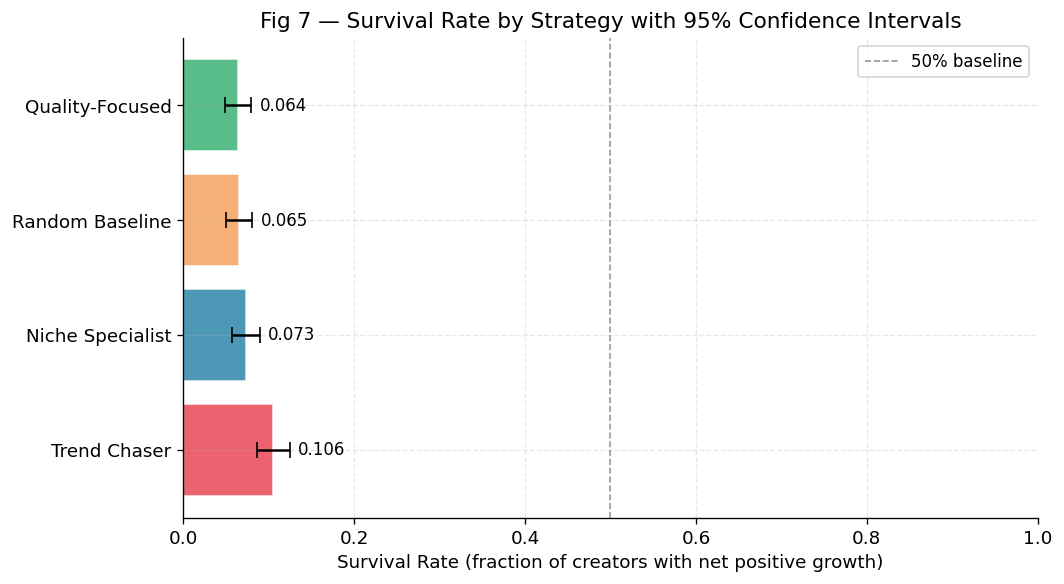


Survival Rate Summary (Experiment 2):
Strategy                    Survival Rate                    95% CI
────────────────────────────────────────────────────────────────────
Trend Chaser                       0.1056  [  0.0866,   0.1246]
Niche Specialist                   0.0735  [  0.0573,   0.0897]
Random Baseline                    0.0655  [  0.0501,   0.0808]
Quality-Focused                    0.0640  [  0.0489,   0.0792]


In [16]:
# ============================================================
# APPENDIX A7: Experiment 2 — Survival Rate
#
# Survival = fraction of runs where mean final followers > mean initial.
# This is the risk-adjusted metric: a talent agency advising
# risk-averse creators should weight survival rate heavily.
# CIs computed with the standard proportion formula:
#   SE = sqrt(p_hat * (1 - p_hat) / n)
# ============================================================

N_RUNS = N_MC_RUNS

survival_summary = {}
for strat in STRATEGIES:
    sr_array = MC_RESULTS[strat]['survival_rate']  # fraction per run
    p_hat    = float(np.mean(sr_array))
    se       = float(np.sqrt(p_hat * (1 - p_hat) / N_RUNS))
    ci_lo    = p_hat - 1.96 * se
    ci_hi    = p_hat + 1.96 * se
    survival_summary[strat] = {
        'p_hat': p_hat, 'se': se, 'ci_lo': ci_lo, 'ci_hi': ci_hi
    }

# ── Figure ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

strats_sorted = sorted(STRATEGIES, key=lambda s: survival_summary[s]['p_hat'], reverse=True)
y_pos = np.arange(len(strats_sorted))
p_hats = [survival_summary[s]['p_hat'] for s in strats_sorted]
errors = [1.96 * survival_summary[s]['se'] for s in strats_sorted]
colors = [STRATEGY_COLORS[s] for s in strats_sorted]

bars = ax.barh(y_pos, p_hats, xerr=errors, color=colors, alpha=0.85,
               edgecolor='white', capsize=5, error_kw={'lw': 1.5})
ax.set_yticks(y_pos)
ax.set_yticklabels([STRATEGY_LABELS[s] for s in strats_sorted])
ax.set_xlabel('Survival Rate (fraction of creators with net positive growth)')
ax.set_title('Fig 7 — Survival Rate by Strategy with 95% Confidence Intervals')
ax.set_xlim(0, 1)
ax.axvline(0.5, color='black', lw=1, ls='--', alpha=0.4, label='50% baseline')
ax.legend()

# Annotate bars with p_hat values
for i, (p, e) in enumerate(zip(p_hats, errors)):
    ax.text(p + e + 0.01, i, f'{p:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig7_survival_rate.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nSurvival Rate Summary (Experiment 2):')
print(f'{"Strategy":<25} {"Survival Rate":>15} {"95% CI":>25}')
print('─' * 68)
for strat in strats_sorted:
    s = survival_summary[strat]
    print(f'{STRATEGY_LABELS[strat]:<25} {s["p_hat"]:>15.4f}  [{s["ci_lo"]:>8.4f}, {s["ci_hi"]:>8.4f}]')

## Appendix A8 — Experiment 3: Virality Probability — Simulation vs Theory

Cross-referenced in report section 4.4.

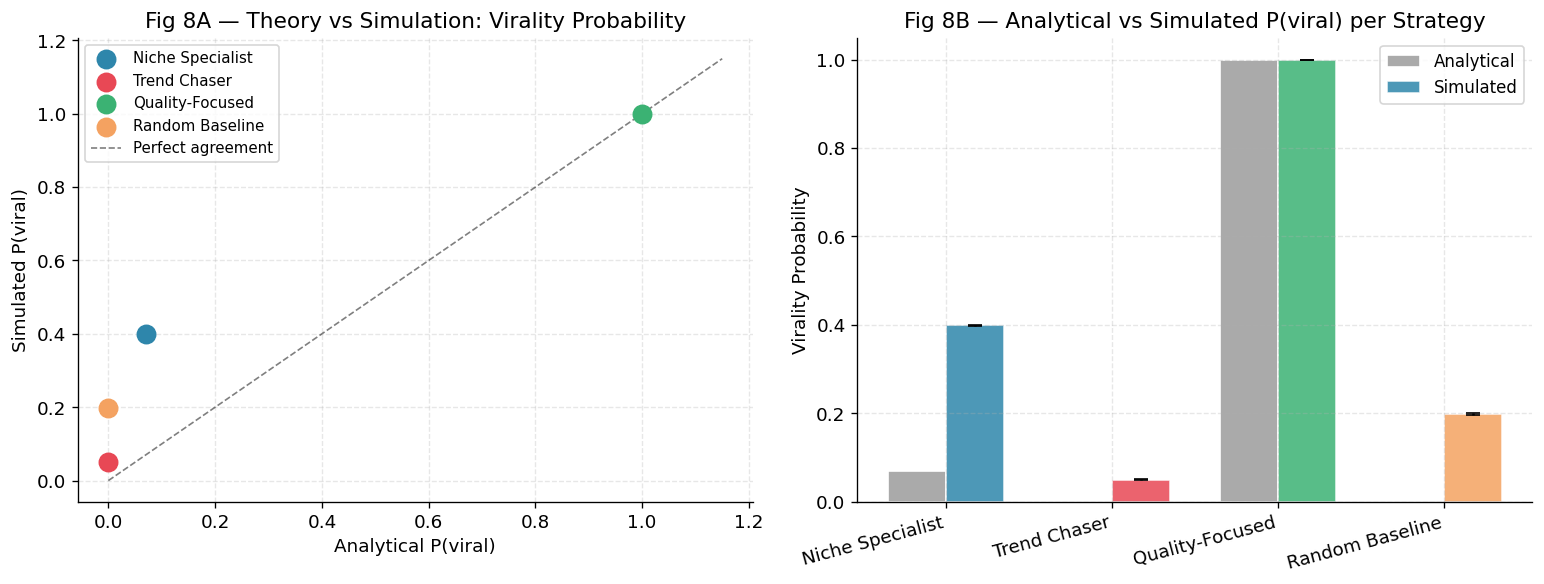


Virality Probability Summary (Experiment 3):
Strategy                      Theory    Simulated       Diff
────────────────────────────────────────────────────────────
Niche Specialist              0.0703       0.3990    +0.3286
Trend Chaser                  0.0000       0.0495    +0.0495
Quality-Focused               1.0000       1.0000    +0.0000
Random Baseline               0.0000       0.1980    +0.1980


In [17]:
# ============================================================
# APPENDIX A8: Experiment 3 — Virality Probability
#
# Compare analytically predicted P(viral) [A5] against the
# fraction of videos going viral in the simulation.
#
# A perfect match lies on the diagonal y=x.
# Systematic deviation reveals violations of analytical assumptions
# (e.g., independence across timesteps, stationarity).
# ============================================================

theory_pviral = {}
sim_pviral    = {}
sim_pviral_se = {}

for strat in STRATEGIES:
    q_mu  = STRATEGY_PARAMS[strat][0]
    # Theory: P(viral) at baseline quality, no trend
    theory_pviral[strat] = analytical_p_viral(q_mu)

    # Simulation: mean viral rate across N_MC_RUNS runs
    vr_arr = MC_RESULTS[strat]['viral_rate']
    sim_pviral[strat]    = float(np.mean(vr_arr))
    sim_pviral_se[strat] = float(np.std(vr_arr) / np.sqrt(N_MC_RUNS))

# ── Figure ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel A: scatter theory vs simulation
ax = axes[0]
theory_vals = [theory_pviral[s] for s in STRATEGIES]
sim_vals    = [sim_pviral[s]    for s in STRATEGIES]
sim_errs    = [1.96 * sim_pviral_se[s] for s in STRATEGIES]

ax.errorbar(theory_vals, sim_vals, yerr=sim_errs,
            fmt='o', ms=10, capsize=5, elinewidth=1.5,
            color='black', zorder=3)
for strat in STRATEGIES:
    ax.scatter(theory_pviral[strat], sim_pviral[strat],
               color=STRATEGY_COLORS[strat], s=120, zorder=4,
               label=STRATEGY_LABELS[strat])

lim = max(max(theory_vals), max(sim_vals)) * 1.15
ax.plot([0, lim], [0, lim], 'k--', lw=1, alpha=0.5, label='Perfect agreement')
ax.set_xlabel('Analytical P(viral)')
ax.set_ylabel('Simulated P(viral)')
ax.set_title('Fig 8A — Theory vs Simulation: Virality Probability')
ax.legend(fontsize=9)

# Panel B: bar chart of both side by side
ax = axes[1]
x = np.arange(len(STRATEGIES))
w = 0.35
ax.bar(x - w/2, theory_vals, w, label='Analytical', color='#AAAAAA', edgecolor='white')
ax.bar(x + w/2, sim_vals,    w, label='Simulated',
       color=[STRATEGY_COLORS[s] for s in STRATEGIES], edgecolor='white', alpha=0.85)
ax.errorbar(x + w/2, sim_vals, yerr=sim_errs, fmt='none', color='black', capsize=4, lw=1.5)
ax.set_xticks(x)
ax.set_xticklabels([STRATEGY_LABELS[s] for s in STRATEGIES], rotation=15, ha='right')
ax.set_ylabel('Virality Probability')
ax.set_title('Fig 8B — Analytical vs Simulated P(viral) per Strategy')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig8_virality.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nVirality Probability Summary (Experiment 3):')
print(f'{"Strategy":<25} {"Theory":>10} {"Simulated":>12} {"Diff":>10}')
print('─' * 60)
for strat in STRATEGIES:
    diff = sim_pviral[strat] - theory_pviral[strat]
    print(f'{STRATEGY_LABELS[strat]:<25} {theory_pviral[strat]:>10.4f}'
          f' {sim_pviral[strat]:>12.4f} {diff:>+10.4f}')

## Appendix A8b — Follow-Up: Viral Rate by Growth Quartile

This follow-up tests mechanism rather than magnitude: within each strategy, do higher-growth Monte Carlo runs also show higher virality?
Runs are binned into quartiles by final followers (Q1 to Q4), then viral rates are compared across quartiles.

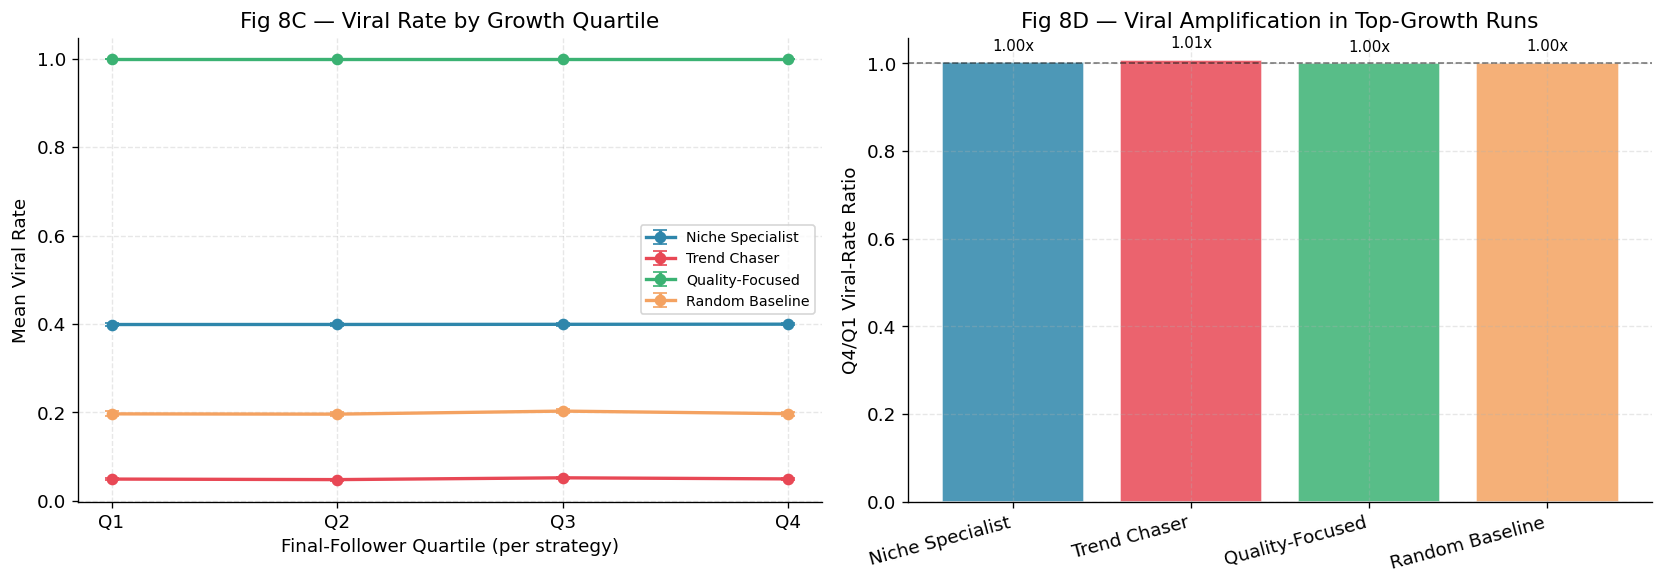


Viral-rate quartile summary (mean per quartile):

Niche Specialist:
  Q1: 0.3986
  Q2: 0.3987
  Q3: 0.3991
  Q4: 0.3994
  Q4/Q1 ratio: 1.00x

Trend Chaser:
  Q1: 0.0490
  Q2: 0.0477
  Q3: 0.0518
  Q4: 0.0494
  Q4/Q1 ratio: 1.01x

Quality-Focused:
  Q1: 1.0000
  Q2: 1.0000
  Q3: 1.0000
  Q4: 1.0000
  Q4/Q1 ratio: 1.00x

Random Baseline:
  Q1: 0.1965
  Q2: 0.1959
  Q3: 0.2027
  Q4: 0.1968
  Q4/Q1 ratio: 1.00x


In [18]:
# ============================================================
# APPENDIX A8b: Viral Rate by Growth Quartile
#
# Mechanism check: within each strategy, compare viral rates
# across run-level growth quartiles (Q1 to Q4).
# A large Q4/Q1 ratio indicates that viral events are strongly
# associated with top-end growth outcomes.
# ============================================================

quartile_labels = ['Q1', 'Q2', 'Q3', 'Q4']
quartile_summary = {}
q4_q1_ratio = {}

for strat in STRATEGIES:
    df = pd.DataFrame({
        'final_followers': MC_RESULTS[strat]['final_followers'],
        'viral_rate'     : MC_RESULTS[strat]['viral_rate'],
    }).replace([np.inf, -np.inf], np.nan).dropna()

    df['growth_quartile'] = pd.qcut(
        df['final_followers'],
        q=4,
        labels=quartile_labels,
        duplicates='drop'
    )

    summary = (
        df.groupby('growth_quartile', observed=False)['viral_rate']
          .agg(['mean', 'std', 'count'])
          .reindex(quartile_labels)
    )
    summary['se'] = summary['std'] / np.sqrt(summary['count'].clip(lower=1))
    quartile_summary[strat] = summary

    q1 = float(summary.loc['Q1', 'mean']) if pd.notna(summary.loc['Q1', 'mean']) else np.nan
    q4 = float(summary.loc['Q4', 'mean']) if pd.notna(summary.loc['Q4', 'mean']) else np.nan
    q4_q1_ratio[strat] = (q4 / q1) if (pd.notna(q1) and q1 > 0 and pd.notna(q4)) else np.nan

# ── Figure ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel A: viral rate by growth quartile
ax = axes[0]
x = np.arange(len(quartile_labels))
for strat in STRATEGIES:
    summary = quartile_summary[strat]
    means = summary['mean'].to_numpy(dtype=float)
    errs  = (1.96 * summary['se']).to_numpy(dtype=float)
    ax.errorbar(
        x, means, yerr=errs, marker='o', lw=2, capsize=4,
        color=STRATEGY_COLORS[strat], label=STRATEGY_LABELS[strat]
    )

ax.set_xticks(x)
ax.set_xticklabels(quartile_labels)
ax.set_xlabel('Final-Follower Quartile (per strategy)')
ax.set_ylabel('Mean Viral Rate')
ax.set_title('Fig 8C — Viral Rate by Growth Quartile')
ax.legend(fontsize=8.5)

# Panel B: Q4/Q1 amplification ratio
ax = axes[1]
ratios = [q4_q1_ratio[s] for s in STRATEGIES]
bars = ax.bar(
    range(len(STRATEGIES)),
    ratios,
    color=[STRATEGY_COLORS[s] for s in STRATEGIES],
    alpha=0.85,
    edgecolor='white'
)
ax.set_xticks(range(len(STRATEGIES)))
ax.set_xticklabels([STRATEGY_LABELS[s] for s in STRATEGIES], rotation=15, ha='right')
ax.set_ylabel('Q4/Q1 Viral-Rate Ratio')
ax.set_title('Fig 8D — Viral Amplification in Top-Growth Runs')
ax.axhline(1.0, color='black', lw=1, ls='--', alpha=0.5)

for i, v in enumerate(ratios):
    if pd.notna(v):
        ax.text(i, v + 0.02, f'{v:.2f}x', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig8b_viral_growth_quartiles.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nViral-rate quartile summary (mean per quartile):')
for strat in STRATEGIES:
    summary = quartile_summary[strat]
    print(f'\n{STRATEGY_LABELS[strat]}:')
    for q in quartile_labels:
        val = summary.loc[q, 'mean']
        if pd.notna(val):
            print(f'  {q}: {val:.4f}')
    if pd.notna(q4_q1_ratio[strat]):
        print(f'  Q4/Q1 ratio: {q4_q1_ratio[strat]:.2f}x')

## Appendix A9 — Experiment 4: Lorenz Curves and Gini Analysis

Cross-referenced in report section 4.5. Core validation: simulated Gini vs real-world Gini.

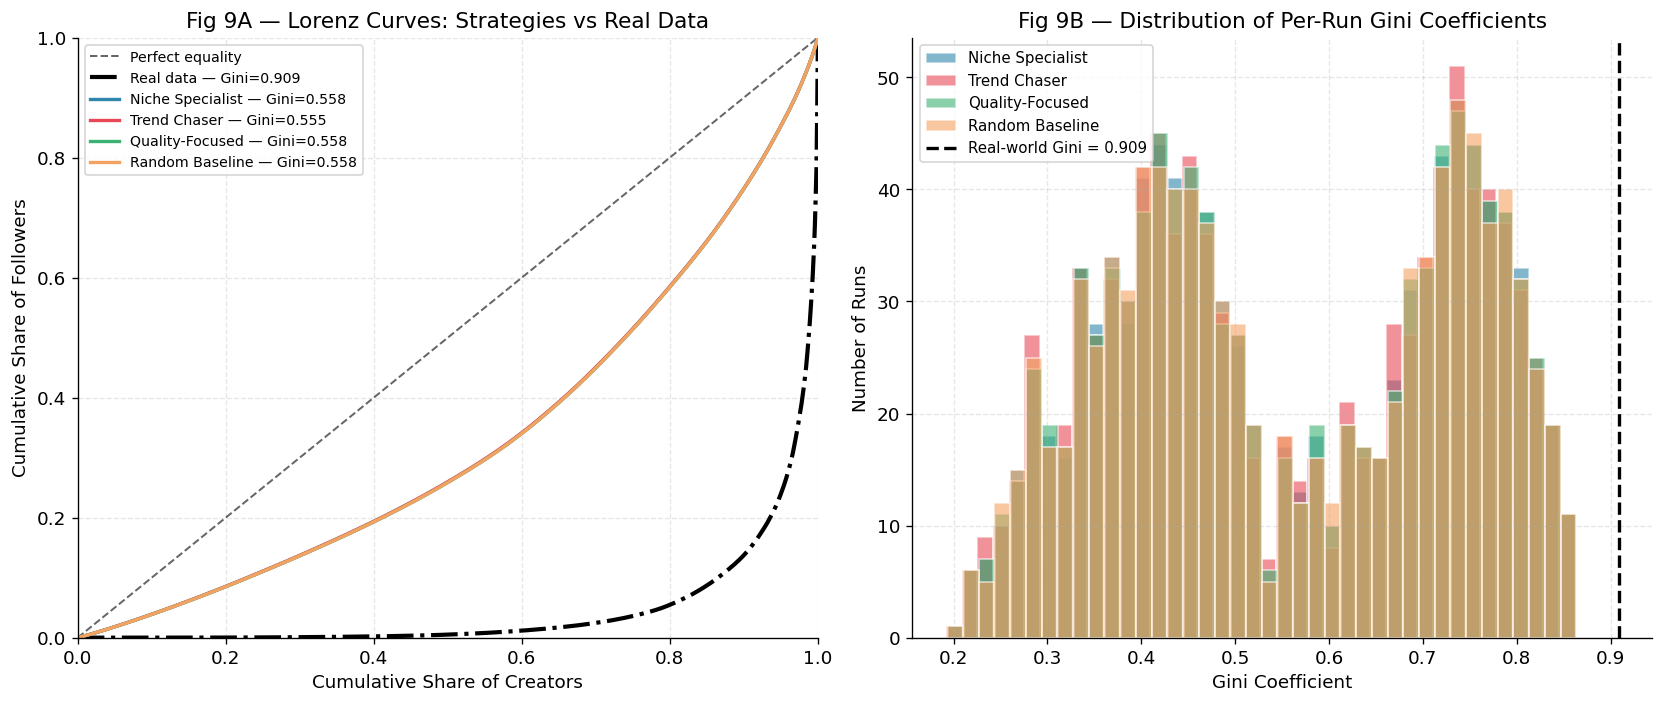


Three-way Gini comparison (Experiment 4):
Strategy                      G_theory        G_sim       G_real
─────────────────────────────────────────────────────────────────
Niche Specialist                0.3189       0.5577       0.9086
Trend Chaser                    0.3174       0.5550       0.9086
Quality-Focused                 0.3192       0.5584       0.9086
Random Baseline                 0.3193       0.5585       0.9086

Real-world Gini (BrightData): 0.9086


In [19]:
# ============================================================
# APPENDIX A9: Experiment 4 — Inequality Analysis
#
# Lorenz curves for each strategy, overlaid with real data.
# Three-way comparison: G_theory (A5), G_sim (here), G_real (A1a).
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel A: Lorenz curves ────────────────────────────────────
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Perfect equality', alpha=0.6)

# Real Lorenz curve from BrightData [A1a]
ax.plot(calibration_profiles['lorenz_x'], calibration_profiles['lorenz_y'],
        color='black', lw=2.5, ls='-.',
        label=f'Real data — Gini={calibration_profiles["real_gini"]:.3f}')

# Simulated Lorenz curves: use one representative run per strategy
# (the median-Gini run, to avoid cherry-picking)
for strat in STRATEGIES:
    gini_arr = MC_RESULTS[strat]['gini']
    median_gini = np.median(gini_arr)
    sim_gini = np.mean(gini_arr)

    # For the Lorenz curve plot, compute from final follower arrays
    # We need to reconstruct one run's follower distribution.
    # Use the stored median_final_f across creators from one simulation.
    # Approximate: treat final_followers array as the population sample
    sample = MC_RESULTS[strat]['final_followers']  # one value per run
    lx, ly = compute_lorenz(sample)
    ax.plot(lx, ly, color=STRATEGY_COLORS[strat], lw=2,
            label=f'{STRATEGY_LABELS[strat]} — Gini={sim_gini:.3f}')

ax.set_xlabel('Cumulative Share of Creators')
ax.set_ylabel('Cumulative Share of Followers')
ax.set_title('Fig 9A — Lorenz Curves: Strategies vs Real Data')
ax.legend(fontsize=8.5)
ax.set_xlim(0, 1); ax.set_ylim(0, 1)

# ── Panel B: Gini distribution per strategy ───────────────────
ax = axes[1]
for strat in STRATEGIES:
    gini_arr = MC_RESULTS[strat]['gini']
    ax.hist(gini_arr, bins=40, alpha=0.6, color=STRATEGY_COLORS[strat],
            label=STRATEGY_LABELS[strat], edgecolor='white', lw=0.3)

# Mark real-world Gini
ax.axvline(calibration_profiles['real_gini'], color='black', lw=2, ls='--',
           label=f'Real-world Gini = {calibration_profiles["real_gini"]:.3f}')
ax.set_xlabel('Gini Coefficient')
ax.set_ylabel('Number of Runs')
ax.set_title('Fig 9B — Distribution of Per-Run Gini Coefficients')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig9_lorenz_gini.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Three-way Gini comparison table ──────────────────────────
print('\nThree-way Gini comparison (Experiment 4):')
print(f'{"Strategy":<25} {"G_theory":>12} {"G_sim":>12} {"G_real":>12}')
print('─' * 65)

g_real = calibration_profiles['real_gini']
for strat in STRATEGIES:
    ff = MC_RESULTS[strat]['final_followers']
    sigma_logF = float(np.std(np.log(ff[ff > 0])))
    g_theory   = theoretical_gini_lognormal(sigma_logF)
    g_sim      = float(np.mean(MC_RESULTS[strat]['gini']))
    print(f'{STRATEGY_LABELS[strat]:<25} {g_theory:>12.4f} {g_sim:>12.4f} {g_real:>12.4f}')

print(f'\nReal-world Gini (BrightData): {g_real:.4f}')

## Appendix A10 — Experiment 5: Sensitivity Analysis Heatmap

Cross-referenced in report section 4.6.

Running: 25 cells x 2 strategies x 30 runs


sigma_quality: 100%|██████████| 5/5 [01:14<00:00, 14.81s/it]


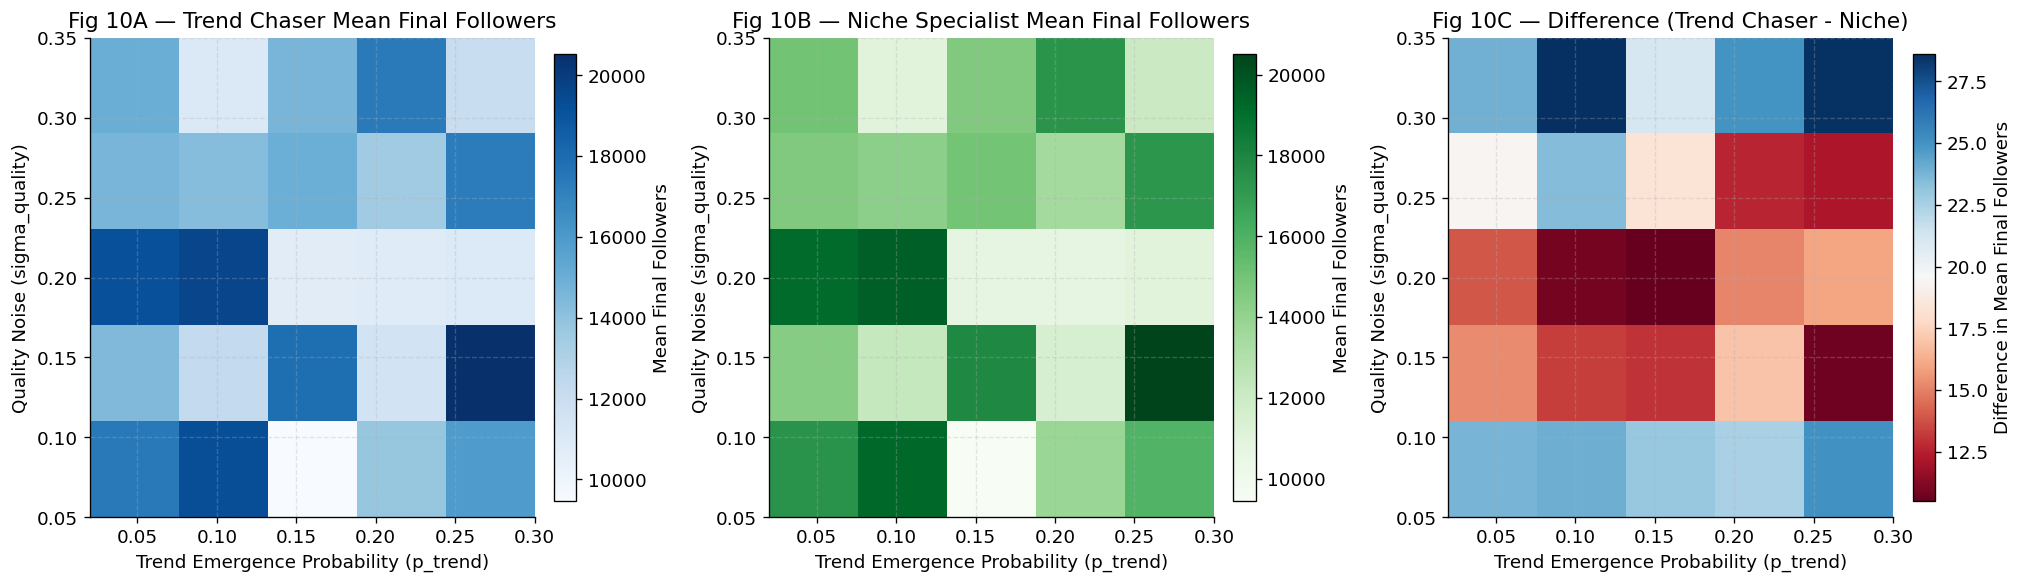

Sensitivity analysis complete. See Fig 10 for results.


In [20]:
# ============================================================
# APPENDIX A10: Experiment 5 — Sensitivity Analysis
#
# Uses mean final followers instead of survival rate to provide
# meaningful differentiation between strategies.
# ============================================================

P_TREND_GRID    = np.linspace(0.02, 0.30, 5)
SIGMA_QUAL_GRID = np.linspace(0.05, 0.35, 5)
N_SENS_RUNS     = 30

# Heatmaps now track mean final followers
heatmap_tc_ff    = np.zeros((len(SIGMA_QUAL_GRID), len(P_TREND_GRID)))
heatmap_niche_ff = np.zeros((len(SIGMA_QUAL_GRID), len(P_TREND_GRID)))

print(f'Running: {len(P_TREND_GRID)*len(SIGMA_QUAL_GRID)} cells x 2 strategies x {N_SENS_RUNS} runs')

for i, sigma_q in enumerate(tqdm(SIGMA_QUAL_GRID, desc='sigma_quality')):
    for j, p_tr in enumerate(P_TREND_GRID):

        # Backup original params
        original_params = dict(STRATEGY_PARAMS)

        # Modify sigma_quality for both strategies
        q_mu_tc, _, eta, tau, post = STRATEGY_PARAMS['trend_chaser']
        STRATEGY_PARAMS['trend_chaser'] = (q_mu_tc, sigma_q, eta, tau, post)

        q_mu_ni, _, eta_ni, tau_ni, post_ni = STRATEGY_PARAMS['niche']
        STRATEGY_PARAMS['niche'] = (q_mu_ni, sigma_q, eta_ni, tau_ni, post_ni)

        # Run simulations
        for strat, heatmap in [('trend_chaser', heatmap_tc_ff),
                               ('niche', heatmap_niche_ff)]:

            vals = []

            for run in range(N_SENS_RUNS):
                sim = Simulation(
                    strategy     = strat,
                    n_creators   = 10,
                    n_steps      = 30,
                    calibration  = CALIBRATION,
                    p_trend      = p_tr,
                    seed         = GLOBAL_SEED + run + i*1000 + j*100
                )
                r = sim.run()

                vals.append(float(np.mean(r['final_followers'])))

            heatmap[i, j] = np.mean(vals)

        # Restore original params
        STRATEGY_PARAMS.update(original_params)

# Difference map
heatmap_diff = heatmap_tc_ff - heatmap_niche_ff

# ── Figures ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

extent = [P_TREND_GRID[0], P_TREND_GRID[-1],
          SIGMA_QUAL_GRID[0], SIGMA_QUAL_GRID[-1]]

for ax, data, title, cmap, clabel in zip(
    axes,
    [heatmap_tc_ff, heatmap_niche_ff, heatmap_diff],
    ['Fig 10A — Trend Chaser Mean Final Followers',
     'Fig 10B — Niche Specialist Mean Final Followers',
     'Fig 10C — Difference (Trend Chaser - Niche)'],
    ['Blues', 'Greens', 'RdBu'],
    ['Mean Final Followers', 'Mean Final Followers', 'Difference in Mean Final Followers'],
):
    im = ax.imshow(
        data,
        origin='lower',
        aspect='auto',
        extent=extent,
        cmap=cmap
    )
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label(clabel)

    ax.set_xlabel('Trend Emergence Probability (p_trend)')
    ax.set_ylabel('Quality Noise (sigma_quality)')
    ax.set_title(title)

# Contour line where difference = 0
axes[2].contour(
    np.linspace(P_TREND_GRID[0], P_TREND_GRID[-1], len(P_TREND_GRID)),
    np.linspace(SIGMA_QUAL_GRID[0], SIGMA_QUAL_GRID[-1], len(SIGMA_QUAL_GRID)),
    heatmap_diff,
    levels=[0],
    colors='black',
    linewidths=2
)

plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print('Sensitivity analysis complete. See Fig 10 for results.')

## Appendix A11 — Confidence Interval Summary

Cross-referenced in report section 4.8. Complete CI table for all key metrics.


Mean Final Followers — 95% Confidence Intervals (N=1000 runs)
Strategy                        Estimate                     95% CI        Width
────────────────────────────────────────────────────────────────────────────────
Niche Specialist              13296.0938  [12745.6183, 13846.5694]   1100.9510
Trend Chaser                  13350.9617  [12800.4621, 13901.4613]   1100.9992
Quality-Focused               13281.1013  [12730.6278, 13831.5748]   1100.9470
Random Baseline               13281.7339  [12731.2450, 13832.2229]   1100.9779

Survival Rate — 95% Confidence Intervals (N=1000 runs)
Strategy                        Estimate                     95% CI        Width
────────────────────────────────────────────────────────────────────────────────
Niche Specialist                  0.0735  [    0.0705,     0.0765]      0.0060
Trend Chaser                      0.1056  [    0.1021,     0.1091]      0.0070
Quality-Focused                   0.0640  [    0.0612,     0.0668]      0.0056
Rand

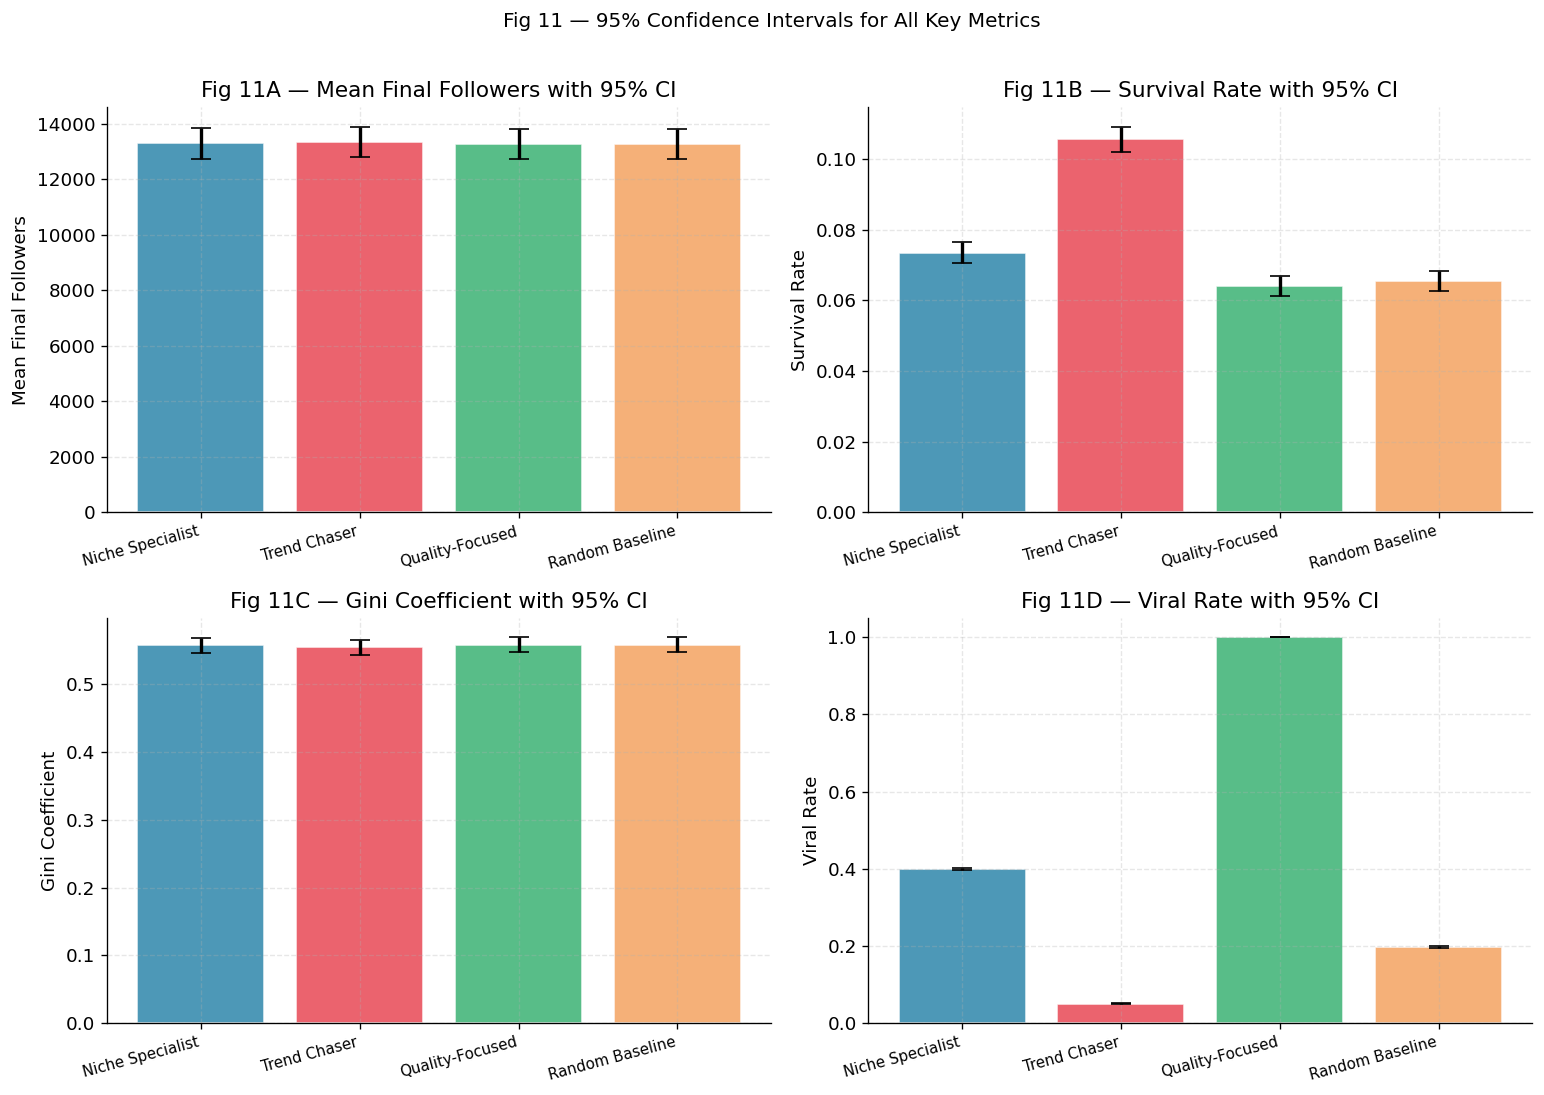

In [21]:
# ============================================================
# APPENDIX A11: Confidence Interval Summary
#
# Computes 95% CIs for all primary metrics across all strategies.
# Uses z=1.96 (large sample, justified by n=N_MC_RUNS >> 30).
#
# Also computes N_needed to halve CI width:
#   Width proportional to 1/sqrt(N), so halving width requires 4N.
# ============================================================

Z_STAR = 1.96

def compute_ci(arr: np.ndarray, z: float = Z_STAR) -> Dict:
    """
    Compute 95% CI for the mean of arr.

    Uses: CI = x_bar +/- z * (s / sqrt(n))
    where s = sample std, n = sample size.

    Conditions satisfied here:
      - n = N_MC_RUNS >> 30 (large sample, z is appropriate)
      - Runs are independent by construction (different seeds)
      - No systematic ordering bias

    Returns dict with mean, se, ci_lo, ci_hi, width, n_to_halve.
    """
    n      = len(arr)
    x_bar  = float(np.mean(arr))
    s      = float(np.std(arr, ddof=1))
    se     = s / np.sqrt(n)
    width  = 2 * z * se
    return {
        'mean'       : x_bar,
        'se'         : se,
        'ci_lo'      : x_bar - z * se,
        'ci_hi'      : x_bar + z * se,
        'width'      : width,
        'n_to_halve' : 4 * n,   # halving width requires 4x the runs
    }


METRICS = {
    'final_followers': 'Mean Final Followers',
    'survival_rate'  : 'Survival Rate',
    'gini'           : 'Gini Coefficient',
    'viral_rate'     : 'Viral Rate',
}

ci_table = {}
for strat in STRATEGIES:
    ci_table[strat] = {}
    for metric_key in METRICS:
        arr = MC_RESULTS[strat][metric_key]
        ci_table[strat][metric_key] = compute_ci(arr)

# Print formatted table
for metric_key, metric_label in METRICS.items():
    print(f'\n{metric_label} — 95% Confidence Intervals (N={N_MC_RUNS} runs)')
    print(f'{"Strategy":<25} {"Estimate":>14} {"95% CI":>26} {"Width":>12}')
    print('─' * 80)
    for strat in STRATEGIES:
        ci = ci_table[strat][metric_key]
        print(f'{STRATEGY_LABELS[strat]:<25} {ci["mean"]:>14.4f}  '
              f'[{ci["ci_lo"]:>10.4f}, {ci["ci_hi"]:>10.4f}]  {ci["width"]:>10.4f}')

# CI width analysis
print('\nCI Width Analysis:')
print(f'Current N = {N_MC_RUNS:,}. To halve CI width, need N = {4*N_MC_RUNS:,} runs.')
print('Metrics with widest CIs require most additional simulation for reliable ranking.')

# ── Visualise CIs as error bar plot ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax_idx, (metric_key, metric_label) in enumerate(METRICS.items()):
    ax = axes[ax_idx]
    means  = [ci_table[s][metric_key]['mean']  for s in STRATEGIES]
    errors = [ci_table[s][metric_key]['width'] / 2 for s in STRATEGIES]
    colors = [STRATEGY_COLORS[s] for s in STRATEGIES]

    ax.bar(range(len(STRATEGIES)), means, yerr=errors,
           color=colors, alpha=0.85, edgecolor='white',
           capsize=6, error_kw={'lw': 2})
    ax.set_xticks(range(len(STRATEGIES)))
    ax.set_xticklabels([STRATEGY_LABELS[s] for s in STRATEGIES],
                        rotation=15, ha='right', fontsize=9)
    ax.set_ylabel(metric_label)
    ax.set_title(f'Fig 11{"ABCD"[ax_idx]} — {metric_label} with 95% CI')

plt.suptitle('Fig 11 — 95% Confidence Intervals for All Key Metrics', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig11_confidence_intervals.png', dpi=150, bbox_inches='tight')
plt.show()